# Modelos de Riesgo de Crédito — Originación y Cobranza


## 1. Carga de datos

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import scorecardpy as sc
import plotly.graph_objects as go
from collections import Counter
from IPython.display import display, Math, Markdown
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from optbinning import OptimalBinning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report, 
                             roc_curve, auc, accuracy_score, balanced_accuracy_score, 
                             mean_absolute_error, mean_squared_error, cohen_kappa_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize
from plotly.subplots import make_subplots
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# Configuración global
semilla = 67
verde, amarillo, rojo = '#2e9e5b', '#e8b400', '#c0392b'

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 10.5, 'font.family': 'serif',
    'axes.grid': True, 'grid.alpha': .3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'bold'
})
sns.set_palette('deep')

In [2]:
#Funciones generales
def es_monotona(woe): # Clasificación de una secuencia de WoE's como decreciente/creciente/No monótona
    d = np.diff(woe)
    if np.all(d >= -1e-9): return 'creciente'
    if np.all(d <=  1e-9): return 'decreciente'
    return 'No monótona'

def _es_numerica(serie):  # True si la columna es numérica (binning numérico); False si es ategórica
    return pd.api.types.is_numeric_dtype(serie)

def ajustar_binning(X, y, variables): # Binning 
    bins = {}
    for v in variables:
        if _es_numerica(X[v]):
            bins[v] = OptimalBinning(name=v, dtype='numerical', monotonic_trend='auto_asc_desc').fit(X[v], y)
        else:
            bins[v] = OptimalBinning(name=v, dtype='categorical').fit(X[v].astype(str), y)
    return bins

def transformar_woe(bins, X, variables): # Aplica la transformación WoE (numéricas y categóricas)
    cols = {}
    for v in variables:
        col = X[v] if _es_numerica(X[v]) else X[v].astype(str)
        cols[f'{v}_woe'] = bins[v].transform(col, metric='woe')
    return pd.DataFrame(cols, index=X.index)

def _bins_reales(optb):
    t = optb.binning_table.build()
    t = t[~t.index.isin(['Totals']) & ~t['Bin'].isin(['Special', 'Missing'])]
    return t[t['Count'] > 0]

def clasificar_iv(iv):  # Discriminador
    if iv < 0.02: return 'Sin poder predictivo'
    if iv < 0.10: return 'Débil'
    if iv < 0.30: return 'Medio'
    if iv < 0.50: return 'Fuerte'
    return 'Revisar'

def tabla_iv(X, y, variables, umbral=0.02):  # IV por variable 
    bins = ajustar_binning(X, y, variables)
    filas = []
    for v in variables:
        iv = bins[v].binning_table.build().loc['Totals', 'IV']
        filas.append({'Variable': v,
                      'Tipo': 'numérica' if _es_numerica(X[v]) else 'categórica',
                      'Tramos': len(_bins_reales(bins[v])),
                      'IV': round(iv, 4),
                      'Poder_predictivo': clasificar_iv(iv),
                      'Seleccionada': 'Sí' if iv >= umbral else 'No'})
    tabla = pd.DataFrame(filas).sort_values('IV', ascending=False).reset_index(drop=True)
    seleccionadas = tabla.loc[tabla['Seleccionada'] == 'Sí', 'Variable'].tolist()
    return tabla, seleccionadas, bins

def graficar_monotonia(bins, variables, titulo): 
    n = len(variables); ncol = 3; nrow = int(np.ceil(n / ncol))
    titulos, resumen, datos = [], [], []
    for v in variables:
        t = _bins_reales(bins[v]); woe = t['WoE'].values
        tend = es_monotona(woe); iv = bins[v].binning_table.build().loc['Totals', 'IV']
        resumen.append({'Variable': v, 'Tramos': len(woe), 'IV': round(iv, 4), 'Monotonía': tend})
        titulos.append(f'{v} (IV={iv:.3f} · {tend})'); datos.append((t, woe))
    specs = [[{'secondary_y': True} for _ in range(ncol)] for _ in range(nrow)]
    fig = make_subplots(rows=nrow, cols=ncol, specs=specs, subplot_titles=titulos,
                        horizontal_spacing=0.09, vertical_spacing=0.16)
    for k, (t, woe) in enumerate(datos):
        r, c = divmod(k, ncol); r += 1; c += 1
        etiquetas = [str(b) for b in t['Bin']]
        fig.add_trace(go.Bar(x=etiquetas, y=woe, marker_color='#2E5496', opacity=.85,
                             name='WoE', showlegend=False), row=r, col=c, secondary_y=False)
        fig.add_trace(go.Scatter(x=etiquetas, y=t['Event rate'].values * 100, mode='lines+markers',
                             line=dict(color=rojo, width=1.8), marker=dict(size=5),
                             name='Tasa de mora', showlegend=False), row=r, col=c, secondary_y=True)
        fig.update_yaxes(title_text='WoE', row=r, col=c, secondary_y=False)
        fig.update_yaxes(title_text='Mora (%)', color=rojo, showgrid=False, row=r, col=c, secondary_y=True)
        fig.update_xaxes(tickangle=-45, tickfont=dict(size=8), row=r, col=c)
    fig.update_layout(template='plotly_white', height=300 * nrow, width=340 * ncol,
                      title_text=titulo, title_x=0.5, font=dict(family='serif', size=11),
                      margin=dict(t=90))
    fig.show()
    return pd.DataFrame(resumen)

def plot_matriz_confusion(y, yhat, fig, row, col):  
    cm = confusion_matrix(y, yhat); labels = ['No Mora', 'Mora']
    fig.add_trace(go.Heatmap(z=cm, x=labels, y=labels, colorscale='Blues', showscale=False,
                             text=cm, texttemplate='%{text}', textfont={'size': 14}),
                  row=row, col=col)
    fig.update_xaxes(title_text='Predicción', row=row, col=col)
    fig.update_yaxes(title_text='Real', autorange='reversed', row=row, col=col)
    return cm

def plot_roc(y, score, fig, row, col, color='#2E5496'): 
    fpr, tpr, _ = roc_curve(y, score); a = auc(fpr, tpr)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', line=dict(width=2, color=color),
                             name=f'AUC = {a:.3f}', showlegend=False), row=row, col=col)
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='grey', width=1),
                             name='Aleatorio (0.5)', showlegend=False), row=row, col=col)
    fig.update_xaxes(title_text='Tasa de Falsos Positivos', range=[0, 1], row=row, col=col)
    fig.update_yaxes(title_text='Tasa de Verdaderos Positivos', range=[0, 1.02], row=row, col=col)
    return a

def evaluar(nombre, y_te, p_te, yhat_te, y_oo, p_oo, yhat_oo): 
    auc_te, auc_oo = roc_auc_score(y_te, p_te), roc_auc_score(y_oo, p_oo)
    print(f'AUC TEST = {auc_te:.4f}   |   AUC OOT = {auc_oo:.4f}\n')
    print('TEST'); print(classification_report(y_te, yhat_te, digits=3, zero_division=0))
    print('OOT');  print(classification_report(y_oo, yhat_oo, digits=3, zero_division=0))
    figc = make_subplots(rows=1, cols=2, horizontal_spacing=0.16,
                         subplot_titles=('Test', 'OOT'))
    plot_matriz_confusion(y_te, yhat_te, figc, 1, 1)
    plot_matriz_confusion(y_oo, yhat_oo, figc, 1, 2)
    figc.update_layout(template='plotly_white', height=380, width=820,
                       title_text=f'Matriz de Confusión {nombre}', title_x=0.5,
                       font=dict(family='serif', size=11))
    figc.show()
    figr = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
                         subplot_titles=(f'Test (AUC={auc_te:.3f})', f'OOT (AUC={auc_oo:.3f})'))
    plot_roc(y_te, p_te, figr, 1, 1); plot_roc(y_oo, p_oo, figr, 1, 2)
    figr.update_layout(template='plotly_white', height=420, width=900, showlegend=False,
                       title_text=f'Curva ROC {nombre}', title_x=0.5, font=dict(family='serif', size=11))
    figr.show()

def estructura_logistica(modelo, woe_features, nombre=''):  
    b0 = modelo.intercept_[0]; betas = modelo.coef_[0]
    nombres_tex = []
    for f in woe_features:
        base = f[:-4] if f.endswith('_woe') else f
        nombres_tex.append(r'\text{WoE}_{\text{%s}}' % base.replace('_', r'\_'))
    simb = (r'\operatorname{logit}(p)=\ln\!\frac{p}{1-p}='
            r'\beta_0+\sum_{j=1}^{%d}\beta_j\,\text{WoE}_j' % len(betas))
    terms = [f'{b:+.4f}\\,{nm}' for b, nm in zip(betas, nombres_tex)]
    lineas = [f'{b0:+.4f}'] + terms
    chunks = [r'\;'.join(lineas[i:i + 3]) for i in range(0, len(lineas), 3)]
    ajust = r'\begin{aligned}\operatorname{logit}(p)=\;&' + r' \\ &'.join(chunks) + r'\end{aligned}'
    prob = r'P(\text{mora}\mid x)=\dfrac{1}{1+e^{-\operatorname{logit}(p)}}'
    display(Markdown(f'**Estructura matemática final — Regresión logística {nombre}**  \n'
                     f'Las variables explicativas son los WoE de cada predictor; '
                     f'intercepto $\\beta_0={b0:.4f}$, con $k={len(betas)}$ términos.'))
    display(Math(simb)); display(Math(ajust)); display(Math(prob))
    return pd.DataFrame({'Término': ['Intercepto (β₀)'] + list(woe_features),
                         'Coeficiente': np.concatenate([[b0], betas])})

def calcular_psi(esperado, actual, n_bins=10):  
    cortes = np.unique(np.quantile(esperado, np.linspace(0, 1, n_bins + 1)))
    cortes[0], cortes[-1] = -np.inf, np.inf
    esp = np.histogram(esperado, cortes)[0] / len(esperado)
    act = np.histogram(actual,   cortes)[0] / len(actual)
    esp, act = np.where(esp==0, 1e-6, esp), np.where(act==0, 1e-6, act)
    psi = (act - esp) * np.log(act / esp)
    tabla = pd.DataFrame({'bin_inf':cortes[:-1], 'bin_sup':cortes[1:],
                          'pct_train':esp, 'pct_oot':act, 'psi_bin':psi})
    return psi.sum(), tabla

def lectura_psi(psi):
    return '1 estable (<0.10)' if psi < .10 else ('1 cambio moderado (0.10–0.25)' if psi < .25 else '3 cambio severo (>0.25)')


def puntaje_total(modelo, X, factor, offset):  # puntaje total del scorecard por crédito
    # Score = offset - factor * logit, con logit = decision_function sobre los WoE
    return offset - factor * modelo.decision_function(X)

def graficar_distribucion_cutoff(scores, y, cutoff, titulo):  # distribución de puntajes + punto de corte
    scores = np.asarray(scores, dtype=float); y = np.asarray(y)
    aprobados = scores >= cutoff
    tasa_aprob = aprobados.mean()
    mora_aprob = y[aprobados].mean() if aprobados.sum() else 0.0
    mora_rech  = y[~aprobados].mean() if (~aprobados).sum() else 0.0
    lo, hi = float(scores.min()), float(scores.max())
    fig = go.Figure()
    fig.add_trace(go.Histogram(x=scores, nbinsx=40, marker_color='#2E5496',
                               marker_line_color='white', marker_line_width=.4, opacity=.85,
                               name='Créditos', showlegend=False))
    fig.add_vrect(x0=lo, x1=cutoff, fillcolor=rojo, opacity=.10, line_width=0,
                  annotation_text=f'Rechazo {100*(1-tasa_aprob):.0f}%', annotation_position='top left')
    fig.add_vrect(x0=cutoff, x1=hi, fillcolor=verde, opacity=.10, line_width=0,
                  annotation_text=f'Aprobación {100*tasa_aprob:.0f}%', annotation_position='top right')
    fig.add_vline(x=cutoff, line_color=rojo, line_width=2, line_dash='dash',
                  annotation_text=f'Punto de corte = {cutoff:.0f}', annotation_position='bottom right')
    fig.update_layout(template='plotly_white', height=440, width=860, bargap=.03,
                      title_text=titulo, title_x=0.5, xaxis_title='Puntaje del scorecard',
                      yaxis_title='N° de créditos', font=dict(family='serif', size=12), margin=dict(b=95))
    fig.show()
    return dict(cutoff=cutoff, tasa_aprobacion=tasa_aprob, mora_aprobados=mora_aprob, mora_rechazados=mora_rech)


In [3]:
df = pd.read_excel( r'C:\Users\rolg0\Downloads\8vo semestre\base_tarjetas_credito 060526.xlsx', sheet_name='Base_General')

df['Target'] = np.where(df['dias_atraso'] > 90, 1, 0)          # default Basilea II  90+ días
print('Dimensiones:', df.shape)
print('\nDistribución del Target (0=al corriente, 1=moroso):')
print(df['Target'].value_counts())
print(f"\nTasa de morosidad: {df['Target'].mean():.4%}")
assert df['Target'].sum() >= 10, f"Solo hay {df['Target'].sum()} morosos"

Dimensiones: (17500, 25)

Distribución del Target (0=al corriente, 1=moroso):
Target
0    17396
1      104
Name: count, dtype: int64

Tasa de morosidad: 0.5943%


### 1.1 Análisis descriptivo de variables principales

In [4]:
num_vars = ['edad', 'score_buro', 'linea_credito', 'saldo_Insoluto', 'porcentaje_uso', 'dias_atraso']
cat_vars = ['sexo', 'nivel_educativo']

# Identificador
print('id_cliente  \t  registros:', df['id_cliente'].shape[0], '| únicos:', df['id_cliente'].nunique(),
      '| duplicados:', df['id_cliente'].duplicated().sum(), '\n')

# Estadísticos de variables numéricas
resumen_num = df[num_vars].describe().T
resumen_num['missing']   = df[num_vars].isna().sum()
resumen_num['asimetria'] = df[num_vars].skew()
resumen_num['curtosis']  = df[num_vars].kurtosis()
print('Estadísticos — variables numéricas:')
display(resumen_num.round(2))

# Tablas de frecuencia de variables categóricas
for v in cat_vars:
    t = df[v].value_counts(dropna=False).rename('frecuencia').to_frame()
    t['porcentaje'] = (t['frecuencia'] / len(df) * 100).round(2)
    print(f'\nDistribución — {v}:')
    display(t)

id_cliente  	  registros: 17500 | únicos: 17500 | duplicados: 0 

Estadísticos — variables numéricas:


,count,mean,std,min,25%,50%,75%,max,missing,asimetria,curtosis
edad,17500.0,40.23,11.70,18.00,32.00,40.00,48.00,75.0,0,0.18,-0.31
score_buro,17500.0,679.58,78.59,350.00,626.00,680.00,734.00,850.0,0,-0.08,-0.22
linea_credito,17500.0,218100.98,169897.64,10091.00,105950.75,171771.00,277751.25,1927749.0,0,2.45,10.42
saldo_Insoluto,17500.0,103469.30,105418.82,1078.00,35237.75,71594.00,133731.00,1422207.0,0,2.80,13.60
porcentaje_uso,17500.0,47.44,24.64,5.01,25.80,47.58,68.75,90.0,0,-0.00,-1.21
dias_atraso,17500.0,21.14,22.45,0.00,0.00,15.00,36.00,131.0,0,1.00,0.39



Distribución — sexo:


,frecuencia,porcentaje
sexo,,
M,8779,50.17
F,8721,49.83



Distribución — nivel_educativo:


,frecuencia,porcentaje
nivel_educativo,,
Posgrado,3535,20.20
Primaria,3517,20.10
Preparatoria,3510,20.06
Licenciatura,3502,20.01
Secundaria,3436,19.63


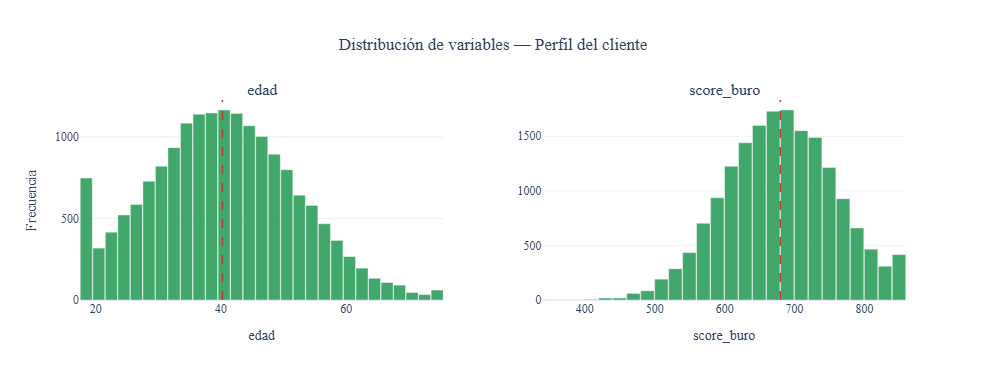

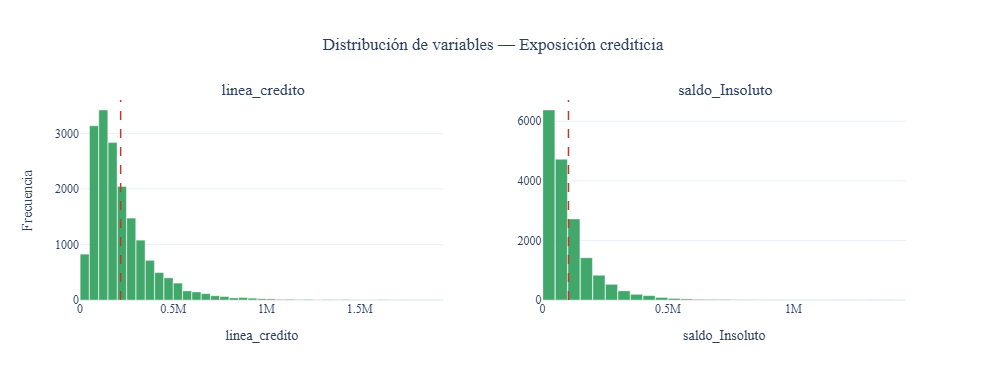

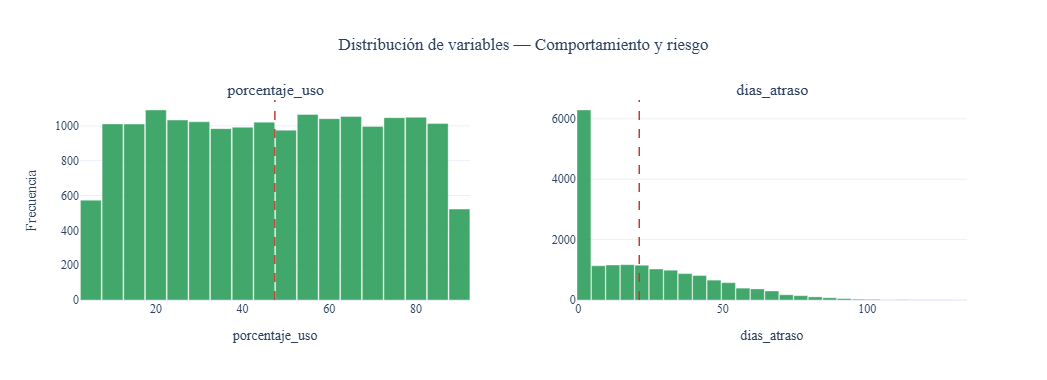

In [5]:
# Gráficos preliminares
paneles = [
    ('edad',          'score_buro'),       # Perfil del cliente
    ('linea_credito', 'saldo_Insoluto'),   # Exposición
    ('porcentaje_uso','dias_atraso'),      # Comportamiento / riesgo
]
titulos = ['Perfil del cliente', 'Exposición crediticia', 'Comportamiento y riesgo']

for (a, b), tit in zip(paneles, titulos):
    fig = make_subplots(rows=1, cols=2, subplot_titles=(a, b), horizontal_spacing=0.12)
    for col, var in enumerate([a, b], start=1):
        fig.add_trace(
            go.Histogram(x=df[var], nbinsx=40, marker_color=verde,
                         marker_line_color='white', marker_line_width=0.4,
                         opacity=0.9, name=var, showlegend=False),
            row=1, col=col)
        # Línea de la media
        fig.add_vline(x=df[var].mean(), line_dash='dash', line_color=rojo,
                      line_width=1.5, row=1, col=col)
        fig.update_xaxes(title_text=var, row=1, col=col)
    fig.update_yaxes(title_text='Frecuencia', row=1, col=1)
    fig.update_layout(template='plotly_white', height=380, width=950, bargap=0.04,
                      title_text=f'Distribución de variables — {tit}', title_x=0.5,
                      font=dict(family='serif', size=12))
    fig.show()

## 2. Cálculo de reservas

El objetivo es seguir los lineamientos de la CNBV para poder asignar una Probabilidad de Incumplimiento y con ello una Reserva para contrarrestar la Perdida Esperada (PE) para cada cliente en nuestra base de datos. En nuestra base de datos solamente nos enfocamos en las hojas llamadas 'Anexo_21_CUB' y 'Anexo_22_CUB'

### 2.1 Evaluación de la Cartera Comercial (Anexo 21)

Siguiendo las instrucciones del Anexo 21 de la CNBV, vamos a asignar un puntaje crediticio total a las dos entradas que tenemos en nuestra base de datos.

In [ ]:
ruta = r'C:\Users\rolg0\Downloads\8vo semestre\base_tarjetas_credito 060526.xlsx'
df_anexo_21 = pd.read_excel(ruta, sheet_name='Anexo_21_CUB')
df_anexo_21.head()

La clave SCIAN que se incluye para cada ID nos indica el sector en el que tienen mayor preponderación cada uno de los clientes. Conocer este sector es necesario para saber que reglas especificas aplican para el calculo del puntaje de cada una de ellos.

In [ ]:
# Diccionarios de sectores económicos
grupos_scian = {
    'Agricola': [11],
    'Explotacion, Energia y Construccion': [21, 22, 23],
    'Manufactura': [31, 32, 33],
    'Comercio': [43, 46],
    'Servicios': [48, 49, 51, 52, 53, 54, 55, 56, 61, 62, 71, 72, 81, 93]
}

diccionario_sectores = {}
for sector, claves in grupos_scian.items():
    for clave in claves:
        diccionario_sectores[clave] = sector

# Asignamos a cada ID

df_anexo_21['Sector'] = df_anexo_21['scian'].map(diccionario_sectores).fillna('Explotacion, Energia y Construccion')
df_anexo_21.head()

#### Factor de riesgo I-A

Corresponde al factor de riesgo experiencia de pago, de acuerdo a información de sociedad de información crediticia. Se incluyen a continuación las funciones para determinar el puntaje correspondiente para cada indicador de riesgo.

In [ ]:
# Porcentaje de pagos en tiempo con entidades financieras bancarias
def puntos_pagos_bancarios(row):
    sector = row['Sector']
    pct = row['Porcentaje_Pagos_Tiempo_Bancarias']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if pct > 99: return 168
        elif pct > 95: return 142
        elif pct > 89: return 119
        elif pct > 73: return 94
        elif pct >= 0: return 65
        else: return 133
    
    # Sector Explotación, etc.
    if sector in ['Explotacion, Energia y Construccion']:
        if pct > 97: return 162
        elif pct > 92: return 125
        elif pct > 85: return 106
        elif pct > 67: return 90
        elif pct >= 0: return 73
        else: return 140
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if pct > 98: return 170
        elif pct > 95: return 140
        elif pct > 91: return 118
        elif pct > 84: return 100
        elif pct > 68: return 82
        elif pct >= 0: return 57
        else: return 150
    
    # Sector Comercio
    if sector in ['Comercio']:
        if pct > 97: return 160
        elif pct > 94: return 124
        elif pct > 88: return 103
        elif pct > 74: return 87
        elif pct >= 0: return 64
        else: return 145
    
    # Sector Servicios
    if sector in ['Servicios']:
        if pct > 97: return 157
        elif pct > 94: return 133
        elif pct > 90: return 120
        elif pct > 82: return 108
        elif pct > 64: return 94
        elif pct >= 0: return 77
        else: return 138

df_anexo_21['Puntos_Pago_Bancario'] = df_anexo_21.apply(puntos_pagos_bancarios, axis=1)
df_anexo_21[['id_cliente', 'Sector', 'Puntos_Pago_Bancario']]

In [ ]:
# Porcentaje de pagos en tiempo con entidades financieras no bancarias
def puntos_pagos_no_bancarios(row):
    sector = row['Sector']
    pct = row['Porcentaje_Pagos_Tiempo_No_Bancarias']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if pct > 91: return 146
        elif pct > 57: return 108
        elif pct >= 0: return 100
        else: return 133
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if pct > 99: return 150
        elif pct > 86: return 126
        elif pct > 50: return 106
        elif pct >= 0: return 99
        else: return 127
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if pct > 98: return 156
        elif pct > 75: return 126
        elif pct >= 0: return 102
        else: return 129
    
    # Sector Comercio
    if sector in ['Comercio']:
        if pct > 99: return 158
        elif pct > 86: return 132
        elif pct > 39: return 106
        elif pct >= 0: return 100
        else: return 129
    
    # Sector Servicios
    if sector in ['Servicios']:
        if pct > 96: return 152
        elif pct > 83: return 132
        elif pct > 40: return 112
        elif pct >= 0: return 106
        else: return 128
 
df_anexo_21['Puntos_Pago_No_Bancario'] = df_anexo_21.apply(puntos_pagos_no_bancarios, axis=1)
df_anexo_21[['id_cliente', 'Sector', 'Puntos_Pago_No_Bancario']]

In [ ]:
# Presencia de quitas
def puntos_quitas(row):
    sector = row['Sector']
    num = row['Presencia_Quitas']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if num == 0: return 133
        elif num == 1: return 113
        else: return 120
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if num == 0: return 127
        elif num == 1: return 119
        else: return 123
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if num == 0: return 131
        elif num == 1: return 124
        else: return 126
    
    # Sector Comercio
    if sector in ['Comercio']:
        if num == 0: return 131
        elif num == 1: return 123
        else: return 127
    
    # Sector Servicios
    if sector in ['Servicios']:
        if num == 0: return 130
        elif num == 1: return 119
        else: return 125

df_anexo_21['Puntos_Quitas'] = df_anexo_21.apply(puntos_quitas, axis=1)
df_anexo_21[['id_cliente', 'Sector', 'Puntos_Quitas']]

#### Factor de Riesgo I-B

Corresponde al factor de riesgo experiencia de pago con la Institución.

In [ ]:
# Máximo número de atrasos en ultimos 4 meses

def puntos_maximo_atrasos(row):
    sector = row['Sector']
    num = row['Maximo_Atrasos_12M']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if num >= 2: return 66
        elif num == 1: return 103
        elif num == 0: return 153
        else: return 128
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if num >= 2: return 64
        elif num == 1: return 96
        elif num == 0: return 157
        else: return 127
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if num >= 3: return 50
        elif num == 2: return 77
        elif num == 1: return 95
        elif num == 0: return 154
        else: return 125
    
    # Sector Comercio
    if sector in ['Comercio']:
        if num >= 3: return 49
        elif num >= 1: return 86
        elif num == 0: return 152
        else: return 119
    
    # Sector Servicios
    if sector in ['Servicios']:
        if num >= 3: return 41
        elif num == 2: return 69
        elif num == 1: return 97
        elif num == 0: return 159
        else: return 128

df_anexo_21['Puntos_Maximo_Atrasos'] = df_anexo_21.apply(puntos_maximo_atrasos, axis=1)
df_anexo_21[['id_cliente', 'Sector', 'Puntos_Maximo_Atrasos']]

In [ ]:
# Promedio de días de mora

def puntos_promedio_mora(row):
    sector = row['Sector']
    num = row['Promedio_Dias_Mora']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if num > 30: return 56
        elif num > 6: return 82
        elif num > 0: return 105
        elif num == 0: return 145
        else: return 125
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if num > 38: return 41
        elif num > 27: return 73
        elif num > 7: return 80
        elif num > 0: return 93
        elif num == 0: return 148
        else: return 121
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if num > 30: return 43
        elif num > 15: return 75
        elif num > 0: return 89
        elif num == 0: return 149
        else: return 119
    
    # Sector Comercio
    if sector in ['Comercio']:
        if num > 30: return 32
        elif num > 13: return 70
        elif num > 0: return 90
        elif num == 0: return 148
        else: return 119
    
    # Sector Servicios
    if sector in ['Servicios']:
        if num > 35: return 53
        elif num > 24: return 78
        elif num > 6: return 90
        elif num > 0: return 101
        elif num == 0: return 148
        else: return 125

df_anexo_21['Puntos_Promedio_Dias_Mora'] = df_anexo_21.apply(puntos_promedio_mora, axis=1)
df_anexo_21[['id_cliente', 'Sector', 'Puntos_Promedio_Dias_Mora']]

Una vez calculados los puntajes correspondientes para cada indicador, obtenemos el puntaje crediticio total, el cual en general es dado por la fórmula:

$$
\textit{Puntaje Crediticio Total}_i = \alpha (\textit{Puntaje Crediticio Cuantitativo}_i) + (1 - \alpha) (\textit{Puntaje Crediticio Cualitativo}_i)
$$

Para los créditos del Anexo 21, se tiene que $\alpha = 1.0$, debido a que no se presenta ningun indicador cualitativo.

In [ ]:
# Puntaje Crediticio Total
puntos = [
    'Puntos_Pago_Bancario',
    'Puntos_Pago_No_Bancario',
    'Puntos_Quitas',
    'Puntos_Maximo_Atrasos',
    'Puntos_Promedio_Dias_Mora'
]
df_anexo_21['Puntaje_Total'] = df_anexo_21[puntos].sum(axis=1)
df_anexo_21_final = df_anexo_21.drop(columns=puntos)
df_anexo_21_final

Como nuestro objetivo es calcular la pérdida esperada para construir una reserva, necesitamos obtener el resto de componentes de la fórmula:

$$
PE_i = PI_i \times SP_i \times EAD_i
$$

Siguiendo las Disposiciones de Caracter General Aplicables a las Instituciones de Crédito de la CNBV, una vez que contemos con el puntaje crediticio total, procedemos a calcular la Probabilidad de Incumplimiento (PI) de cada crédito. La fórmula para calcularla esta dada por el Artículo 112 de dicho documento:

$$
PI_i = \frac{1}{1 + e^{- (500 \textit{Puntaje Crediticio Total}_i) \times \frac{\ln(2)}{40}}}
$$

In [ ]:
# Función para la probabilidad de incumplimiento PI
def calcular_pi(puntaje):
    
    z = (500 - puntaje) * (np.log(2)/40)
    pi = 1 / (1 + np.exp(-z))
    return pi

# Asignamos la PI
df_anexo_21_final['PI'] = df_anexo_21_final['Puntaje_Total'].apply(calcular_pi)
df_anexo_21_final[['id_cliente', 'Puntaje_Total', 'PI']]

La Exposición al Incumplimiento (EAD) corresponde al Saldo Insoluto del cliente en cuestión, la cuál se puede extraer de la hoja "Base General" de la base de datos original.

In [ ]:
# Obtenemos la exposición al incumplimiento EAD
df_base_general = pd.read_excel(ruta, sheet_name='Base_General')[['id_cliente', 'saldo_Insoluto']]
df_anexo_21_final = pd.merge(df_anexo_21_final, df_base_general, on='id_cliente', how='left')
df_anexo_21_final = df_anexo_21_final.rename(columns={'saldo_Insoluto': 'EAD'})
df_anexo_21_final[['id_cliente', 'Puntaje_Total', 'PI', 'EAD']]

Por último la Severidad de la Pérdida (SP) se obtiene siguiendo las indicaciones de la tabla del Artículo 2 Bis 73 de las Disposiciones Generales. Debido a las características de los clientes que estamos analizando y a que se asume que no hay presencia de garantías, en este caso todos nuestros clientes tendrán una SP del 55% (clasificados en el Artículo 110, primer párrafo, fracción V, inciso a) de las presentes disposiciones). Con ello, procedemos al cálculo de la Perdida Esperada para cada cliente:

In [ ]:
# Reserva PCE = PI * SP * EAD
df_anexo_21_final['SP'] = 0.55
df_anexo_21_final['Reserva'] = df_anexo_21_final['PI'] * df_anexo_21_final['SP'] * df_anexo_21_final['EAD']
df_anexo_21_final[['id_cliente', 'Puntaje_Total', 'PI', 'SP', 'EAD', 'Reserva']]

### 3.2 Evaluación de Grandes Corporativos (Anexo 22)
Siguiendo la misma lógica, buscamos obtener la Perdida Esperada para los clientes que se rigen bajo el Anexo 22.

In [ ]:
df_anexo_22 = pd.read_excel(ruta, sheet_name='Anexo_22_CUB')
df_anexo_22.head()

In [ ]:
# Asignamos a cada ID

df_anexo_22['Sector'] = df_anexo_22['scian'].map(diccionario_sectores).fillna('Explotacion, Energia y Construccion')
df_anexo_22.head()

#### Factor de riesgo I-A

Correspondiente al factor de riesgo experiencia de pago, de acuerdo a información de sociedad de información crediticia.

In [ ]:
# Porcentaje de pagos en tiempo con entidades financieras bancarias
def puntos_pagos_bancarios_22(row):
    sector = row['Sector']
    pct = row['Porcentaje_Pagos_Bancarios']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if pct > 94: return 103
        elif pct > 74: return 83
        elif pct > 60: return 36
        elif pct >= 0: return 15
        else: return 70
    
    # Sector Explotación, etc.
    if sector in ['Explotacion, Energia y Construccion']:
        if pct > 99: return 127
        elif pct > 92: return 96
        elif pct >= 0: return 54
        else: return 71
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if pct > 99: return 115
        elif pct > 95: return 87
        elif pct > 92: return 64
        elif pct > 85: return 37
        elif pct >= 0: return 2
        else: return 94
    
    # Sector Comercio
    if sector in ['Comercio']:
        if pct > 93: return 102
        elif pct > 88: return 62
        elif pct > 82: return 43
        elif pct > 65: return 23
        elif pct >= 0: return 3
        else: return 98
    
    # Sector Servicios
    if sector in ['Servicios']:
        if pct > 99: return 115
        elif pct > 97: return 107
        elif pct > 91: return 97
        elif pct > 76: return 88
        elif pct > 57: return 77
        elif pct >= 0: return 54
        else: return 114
 
df_anexo_22['Puntos_Pago_Bancario'] = df_anexo_22.apply(puntos_pagos_bancarios_22, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Puntos_Pago_Bancario']]

In [ ]:
# Porcentaje de pagos en tiempo con entidades financieras no bancarias
def puntos_pagos_no_bancarios_22(row):
    sector = row['Sector']
    pct = row['Porcentaje_Pagos_No_Bancarios']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if pct > 96: return 95
        elif pct > 78: return 87
        elif pct >= 0: return 68
        else: return 69
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if pct > 99: return 118
        elif pct > 78: return 91
        elif pct >= 0: return 64
        else: return 83
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if pct > 98: return 97
        elif pct > 91: return 78
        elif pct > 73: return 47
        elif pct >= 0: return 37
        else: return 82
    
    # Sector Comercio
    if sector in ['Comercio']:
        if pct > 98: return 103
        elif pct > 88: return 78
        elif pct >= 0: return 52
        else: return 89
    
    # Sector Servicios
    if sector in ['Servicios']:
        if pct > 99: return 107
        elif pct > 81: return 98
        elif pct >= 0: return 90
        else: return 104

df_anexo_22['Puntos_Pago_No_Bancario'] = df_anexo_22.apply(puntos_pagos_no_bancarios_22, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Puntos_Pago_No_Bancario']]

#### Factor de Riesgo I-B
Correspondiente al factor de riesgo experiencia de pago con la Institución.

In [ ]:
# Máximo número de atrasos en ultimos 7 meses

def puntos_maximo_atrasos_22(row):
    sector = row['Sector']
    num = row['Max_Num_Atrasos_7m']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if num >= 3: return -100
        elif num == 2: return -50
        elif num == 1: return 39
        elif num == 0: return 86
        else: return 63
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if num >= 3: return -57
        elif num == 2: return 12
        elif num == 1: return 58
        elif num == 0: return 121
        else: return 90
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if num >= 3: return -28
        elif num == 2: return 22
        elif num == 1: return 53
        elif num == 0: return 86
        else: return 70
    
    # Sector Comercio
    if sector in ['Comercio']:
        if num >= 3: return -43
        elif num == 2: return 11
        elif num == 1: return 39
        elif num == 0: return 98
        else: return 69
    
    # Sector Servicios
    if sector in ['Servicios']:
        if num >= 3: return -11
        elif num == 2: return 24
        elif num == 1: return 73
        elif num == 0: return 115
        else: return 94

df_anexo_22['Puntos_Maximo_Atrasos'] = df_anexo_22.apply(puntos_maximo_atrasos_22, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Puntos_Maximo_Atrasos']]

In [ ]:
# Porcentaje de saldo sin días de atraso en los últimos 4 meses

def porcentaje_sin_atraso(row):
    sector = row['Sector']
    num = row['Porcentaje_Saldo_Sin_Atraso']
    
    # Sector agrícola
    if sector in ['Agricola']:
        if num >= 98: return 79
        elif num >= 68: return 66
        elif num >= 47: return 58
        elif num >= 0: return 51
        else: return 73
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if num >= 100: return 102
        elif num >= 95: return 86
        elif num >= 71: return 81
        elif num >= 50: return 73
        elif num >= 0: return 66
        else: return 94
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if num >= 96: return 85
        elif num >= 82: return 68
        elif num >= 67: return 66
        elif num >= 0: return 53
        else: return 77
    
    # Sector Comercio
    if sector in ['Comercio']:
        if num >= 100: return 92
        elif num >= 93: return 64
        elif num >= 56: return 54
        elif num >= 0: return 33
        else: return 78
    
    # Sector Servicios
    if sector in ['Servicios']:
        if num >= 100: return 107
        elif num >= 87: return 88
        elif num >= 65: return 78
        elif num >= 0: return 55
        else: return 98

df_anexo_22['Puntos_Saldo_Sin_Atraso'] = df_anexo_22.apply(porcentaje_sin_atraso, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Puntos_Saldo_Sin_Atraso']]

#### Factor de Riesgo I-C

Correspondie al factor de riesgo financiero. Para este factor es necesario el cálculo de algunas razones financieras. El cálculo de estas se especifica añ final del anexo 22. En este caso, sólo calculamos aquellas que sean necesarias para los clientes contemplados.

In [ ]:
# Razón de efectivo a activo total

def efectivo_activo_total(row):
    sector = row['Sector']
    efectivo = row['Efectivo']
    activo_total = row['Activo_Total']
    razon = efectivo/activo_total
    
    # Sector agrícola
    if sector in ['Agricola']:
        if razon >= 2.2: return 109
        elif razon >= 0.1: return 88
        elif razon < 0.1: return 78
        else: return 73
    
    # Sector Manufactura
    elif sector in ['Manufactura']:
        if razon >= 7.7: return 118
        elif razon >= 0.6: return 103
        elif razon < 0.6: return 86
        else: return 63
    
    # Sector Comercio
    elif sector in ['Comercio']:
        if razon >= 1.6: return 108
        elif razon >= 0.3: return 98
        elif razon < 0.3: return 81
        else: return 61
    
    else: return 0

df_anexo_22['Razon_Efectivo_Activo_Total'] = df_anexo_22.apply(efectivo_activo_total, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Razon_Efectivo_Activo_Total']]

In [ ]:
# Razón de cobertura de interés

def cobertura_interes(row):
    sector = row['Sector']
    u_operacion = row['Utilidad_Operacion']
    gastos = row['Gastos_Intereses']
    razon = u_operacion/gastos
    
    # Sector agrícola
    if sector in ['Agricola']:
        if razon >= 3.5: return 123
        elif razon >= 2.4: return 105
        elif razon >= 0: return 87
        elif razon < 0: return 77
        else: return 68
    
    # Sector Explotación, etc
    elif sector in ['Explotacion, Energia y Construccion']:
        if razon >= 1.6: return 108
        elif razon >= 0: return 102
        elif razon >= -3.69: return 98
        elif razon < -3.69: return 91
        else: return 88
    
    else: return 0

df_anexo_22['Razon_Cobertura_Interes'] = df_anexo_22.apply(cobertura_interes, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Razon_Cobertura_Interes']]

In [ ]:
# Razón del efectivo

#NOTA: Asumimos que la inversión a corto plazo es 0

def razon_efectivo(row):
    sector = row['Sector']
    efectivo = row['Efectivo']
    inversiones = 0
    pasivo = row['Pasivo_Circulante']
    razon = (efectivo + inversiones)/pasivo
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if razon >= 1.9: return 113
        elif razon >= 0.7: return 99
        elif razon < 0.7: return 88
        else: return 84
    
    # Sector Servicios
    elif sector in ['Servicios']:
        if razon >= 23.4: return 120
        elif razon >= 4.1: return 115
        elif razon >= 0.3: return 108
        elif razon < 0.3: return 97
        else: return 40
    
    else: return 0

df_anexo_22['Razon_Efectivo'] = df_anexo_22.apply(razon_efectivo, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Razon_Efectivo']]

In [ ]:
# Razón de uso de activos fijos

#NOTA: Supondremos que los Ingresos Anuales son las Ventas Netas

def uso_activos_fijos(row):
    sector = row['Sector']
    ingresos = row['Ventas_Netas']
    denominador = row['Propiedad_Planta_Equipo']
    razon = ingresos/denominador
    
    # Sector Explotación, etc
    if sector in ['Explotacion, Energia y Construccion']:
        if razon >= 26.6: return 119
        elif razon >= 3.87: return 109
        elif razon < 3.87: return 100
        else: return 85
    
    else: return 0

df_anexo_22['Razon_Uso_Activos_Fijos'] = df_anexo_22.apply(uso_activos_fijos, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Razon_Uso_Activos_Fijos']]

In [ ]:
# Razón de costo de financiamiento a ventas

#NOTA: Supondremos que los Ingresos Anuales son las Ventas Netas

def costo_financiamiento_ventas(row):
    sector = row['Sector']
    gastos = row['Gastos_Intereses']
    ingresos = row['Ventas_Netas']
    razon = gastos/ingresos
    
    # Sector Manufactura
    if sector in ['Manufactura']:
        if razon >= 4.5: return 65
        elif razon >= 2.4: return 90
        elif razon >= 1.8: return 100
        elif razon < 1.8: return 110
        else: return 68
    
    # Sector Comercio
    elif sector in ['Comercio']:
        if razon >= 4.8: return 85
        elif razon >= 1.4: return 91
        elif razon < 1.4: return 96
        else: return 83
    
    else: return 0

df_anexo_22['Razon_Costo_Financiamiento_Ventas'] = df_anexo_22.apply(costo_financiamiento_ventas, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Razon_Costo_Financiamiento_Ventas']]

In [ ]:
# Rotación de activos totales

#NOTA: Supondremos que los Ingresos Anuales son las Ventas Netas

def rotacion_activos(row):
    sector = row['Sector']
    ingresos = row['Ventas_Netas']
    activo = row['Activo_Total']
    razon = ingresos/activo
    
    # Sector Comercio
    if sector in ['Comercio']:
        if razon >= 1.57: return 114
        elif razon >= 1.28: return 102
        elif razon >= 0.93: return 82
        elif razon < 0.93: return 78
        else: return 54
    
    else: return 0

df_anexo_22['Rotacion_Activos_Totales'] = df_anexo_22.apply(rotacion_activos, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Rotacion_Activos_Totales']]

In [ ]:
# Periodo de pago de acreedores

def periodo_pago_acreedores(row):
    sector = row['Sector']
    proveedores = row['Proveedores']
    prestamos = row['Prestamos_CP']
    costo = row['Costo_Ventas']
    razon = ((proveedores + prestamos)/costo) * 365
    
    # Sector Comercio
    if sector in ['Comercio']:
        if razon >= 431: return 79
        elif razon >= 215: return 88
        elif razon >= 100: return 92
        elif razon < 100: return 97
        else: return 76
    
    else: return 0

df_anexo_22['Periodo_Pago_Acreedores'] = df_anexo_22.apply(periodo_pago_acreedores, axis=1)
df_anexo_22[['id_cliente', 'Sector', 'Periodo_Pago_Acreedores']]

#### Puntaje cualitativo

Aunque para el Anexo 22 sí existe el puntaje cualitativo, no hay información para su correcta determinación en la base de datos actual, por lo que solo tomamos el puntaje correspondiente a 'Sin Información'.

In [ ]:
# Estabilidad económica
df_anexo_22['Estabilidad_Economica'] = 121

# Intensidad y características de la competencia
df_anexo_22['Intensidad_Competencia'] = 123

# Clientes
df_anexo_22['Clientes'] = 100

# Estados financieros auditados
df_anexo_22['Estados_Auditados'] = 124

# Estructura organizacional
df_anexo_22['Estructura_Organizacional'] = 70

# Composición accionaria
df_anexo_22['Composicion_Accionaria'] = 127

df_anexo_22[['id_cliente', 'Estabilidad_Economica', 'Intensidad_Competencia', 'Clientes', 'Estados_Auditados', 'Estructura_Organizacional', 'Composicion_Accionaria']]

Siguiendo la fórmula para el cálculo del puntaje total:

$$
\textit{Puntaje Crediticio Total}_i = \alpha (\textit{Puntaje Crediticio Cuantitativo}_i) + (1 - \alpha) (\textit{Puntaje Crediticio Cualitativo}_i)
$$

En este caso asumimos que todos nuestros clientes recaen en la categoría de Grandes Corporativos, por lo que aquí $\alpha = 0.85$.

In [ ]:
# Puntaje Crediticio Total
puntos_cuant = [
    'Puntos_Pago_Bancario',
    'Puntos_Pago_No_Bancario',
    'Puntos_Maximo_Atrasos',
    'Puntos_Saldo_Sin_Atraso',
    'Razon_Efectivo_Activo_Total',
    'Razon_Cobertura_Interes',
    'Razon_Efectivo',
    'Razon_Uso_Activos_Fijos',
    'Razon_Costo_Financiamiento_Ventas',
    'Rotacion_Activos_Totales',
    'Periodo_Pago_Acreedores'
]

puntos_cual = [
    'Estabilidad_Economica',
    'Intensidad_Competencia',
    'Clientes', 'Estados_Auditados',
    'Estructura_Organizacional',
    'Composicion_Accionaria'
]

df_anexo_22['Puntaje_Total'] = 0.85*df_anexo_22[puntos_cuant].sum(axis=1) + 0.15*df_anexo_22[puntos_cual].sum(axis=1)
df_anexo_22_final = df_anexo_22.drop(columns = puntos_cuant + puntos_cual)
df_anexo_22_final

Siguiendo las disposiciones generales (Artículo 2 Bis 73), estos créditos tendrán una SP del 45% (Clasificados en el Artículo 110, primer párrafo, fracciones I, III, IV y V, inciso b de las presentes disposiciones). Usando la misma la misma lógica que en el anexo 21 para la PI y la EAD, procedemos a obtener la Reserva:

In [ ]:
# Asignamos la PI
df_anexo_22_final['PI'] = df_anexo_22_final['Puntaje_Total'].apply(calcular_pi)
df_anexo_22_final[['id_cliente', 'Puntaje_Total', 'PI']]

In [ ]:
# Obtenemos la exposición al incumplimiento EAD
df_anexo_22_final = pd.merge(df_anexo_22_final, df_base_general, on='id_cliente', how='left')
df_anexo_22_final = df_anexo_22_final.rename(columns={'saldo_Insoluto': 'EAD'})
df_anexo_22_final[['id_cliente', 'Puntaje_Total', 'PI', 'EAD']]

In [ ]:
# Reserva PCE = PI * SP * EAD
df_anexo_22_final['SP'] = 0.45
df_anexo_22_final['Reserva'] = df_anexo_22_final['PI'] * df_anexo_22_final['SP'] * df_anexo_22_final['EAD']
df_anexo_22_final[['id_cliente', 'Puntaje_Total', 'PI', 'SP', 'EAD', 'Reserva']]

## 3. Modelo de Originación 

Se usa una regresión logística sobre variables transformadas a Wo

In [6]:
# Variables candidatas de Originación, separadas por tipo para tratarlas correctamente
vars_num_orig = ['edad', 'ingreso_mensual', 'score_buro', 'linea_credito', 'porcentaje_uso', 'saldo_Insoluto']
vars_cat_orig = ['sexo', 'estado_civil', 'nivel_educativo']
'edad', 'ingreso_mensual', 'score_buro', 'linea_credito', 'porcentaje_uso', 'saldo_Insoluto', 'sexo', 'estado_civil', 'nivel_educativo'
vars_orig = vars_num_orig + vars_cat_orig

for c in vars_num_orig + ['dias_atraso']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
for c in vars_cat_orig:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '': np.nan})
df = df.dropna(subset=vars_orig + ['dias_atraso']).reset_index(drop=True)
df['Target'] = np.where(df['dias_atraso'] > 90, 1, 0)

### 3.1 Partición Train / Test / Out-of-Time

Si el AUC se sostiene y el PSI es bajo en OOT, el modelo es apto, en cambio, si el PSI sube, se tiene que  recalibrar o re-desarrollar el modelo antes de seguir usándolo.


In [7]:
# 60% train / 20% test / 20% OOT 
dfo = df.sample(frac=1, random_state=semilla).reset_index(drop=True)
n = len(dfo)
train = dfo.iloc[:int(n*.60)]
test  = dfo.iloc[int(n*.60):int(n*.80)]
oot   = dfo.iloc[int(n*.80):]
print(f'train={len(train)}  test={len(test)}  oot={len(oot)}')
print('Morosos   [train]:', train.Target.sum(), '| [test]:', test.Target.sum(), '| [oot]:', oot.Target.sum())

train=10500  test=3500  oot=3500
Morosos   [train]: 63 | [test]: 20 | [oot]: 21


### 3.2 Selección de variables por *Information Value* (IV)

Antes de entrenar se filtran las variables por su **Valor de Información (IV)**, calculado sobre el *train* con su distribución real (sin balancear, que es como debe medirse el IV). Se conservan solo las que superan el umbral estándar (`IV ≥ 0.02`); el resto se descarta por aportar poder predictivo nulo. La tabla `tabla_iv_orig` resume IV, tipo y poder predictivo de cada variable y es la que se lleva al reporte.

In [8]:
UMBRAL_IV = 0.02   # umbral de selección (convención de Siddiqi: IV < 0.02 = sin poder predictivo)

# IV sobre el train con su distribución REAL (antes de balancear)
tabla_iv_orig, vars_sel, _bins_iv_orig = tabla_iv(train[vars_orig], train['Target'], vars_orig, umbral=UMBRAL_IV)

print(f'Variables candidatas: {len(vars_orig)}  ->  seleccionadas (IV ≥ {UMBRAL_IV}): {len(vars_sel)}')
print('Seleccionadas:', vars_sel)
_desc = [v for v in vars_orig if v not in vars_sel]
print('Descartadas:  ', _desc if _desc else '(ninguna)')
print('\nTabla de Information Value — Originación:')
display(tabla_iv_orig)


Variables candidatas: 9  ->  seleccionadas (IV ≥ 0.02): 7
Seleccionadas: ['ingreso_mensual', 'score_buro', 'saldo_Insoluto', 'estado_civil', 'linea_credito', 'porcentaje_uso', 'edad']
Descartadas:   ['sexo', 'nivel_educativo']

Tabla de Information Value — Originación:


,Variable,Tipo,Tramos,IV,Poder_predictivo,Seleccionada
0,ingreso_mensual,numérica,4,0.1586,Medio,Sí
1,score_buro,numérica,5,0.0895,Débil,Sí
2,saldo_Insoluto,numérica,3,0.0882,Débil,Sí
3,estado_civil,categórica,4,0.0807,Débil,Sí
4,linea_credito,numérica,5,0.0756,Débil,Sí
5,porcentaje_uso,numérica,3,0.0565,Débil,Sí
6,edad,numérica,2,0.0295,Débil,Sí
7,nivel_educativo,categórica,5,0.0016,Sin poder predictivo,No
8,sexo,categórica,2,0.0000,Sin poder predictivo,No


### 3.3 Balanceo de clases: submuestreo vs. sobremuestreo

- **Sobremuestreo (over-sampling, `SMOTE`):** crea ejemplos *sintéticos* de morosos interpolando entre vecinos cercanos. Conserva toda la información de la clase mayoritaria, pero puede introducir ruido y algo de sobreajuste.
- **Submuestreo (under-sampling, `RandomUnderSampler`):** elimina aleatoriamente clientes "al corriente" hasta equilibrar. Entrena más rápido y sin datos sintéticos, pero descarta información real.

In [9]:
tecnica = 'over'   # 'over' = SMOTE/SMOTENC (sobremuestreo) | 'under' = RandomUnderSampler (submuestreo)

# Índices de las categóricas que pasaron el filtro IV (SMOTENC las trata como nominales, no las interpola)
cat_sel  = [c for c in vars_cat_orig if c in vars_sel]
idx_cat  = [vars_sel.index(c) for c in cat_sel]

if tecnica == 'over':
    sampler = SMOTENC(categorical_features=idx_cat, random_state=semilla) if idx_cat else SMOTE(random_state=semilla)
else:
    sampler = RandomUnderSampler(random_state=semilla)

X_res, y_res = sampler.fit_resample(train[vars_sel], train['Target'])
train_bal = pd.concat([pd.DataFrame(X_res, columns=vars_sel),
                       pd.Series(y_res, name='Target')], axis=1)
# Restablece tipos tras el remuestreo (numéricas a número, categóricas a texto)
for c in vars_num_orig:
    if c in train_bal: train_bal[c] = pd.to_numeric(train_bal[c], errors='coerce')
for c in cat_sel:
    train_bal[c] = train_bal[c].astype(str)
print(f'Técnica = {tecnica}\nDistribución del train tras balanceo:')
print(train_bal['Target'].value_counts())


Técnica = over
Distribución del train tras balanceo:
Target
0    10437
1    10437
Name: count, dtype: int64


### 4.4 Binning monótono (WoE) 

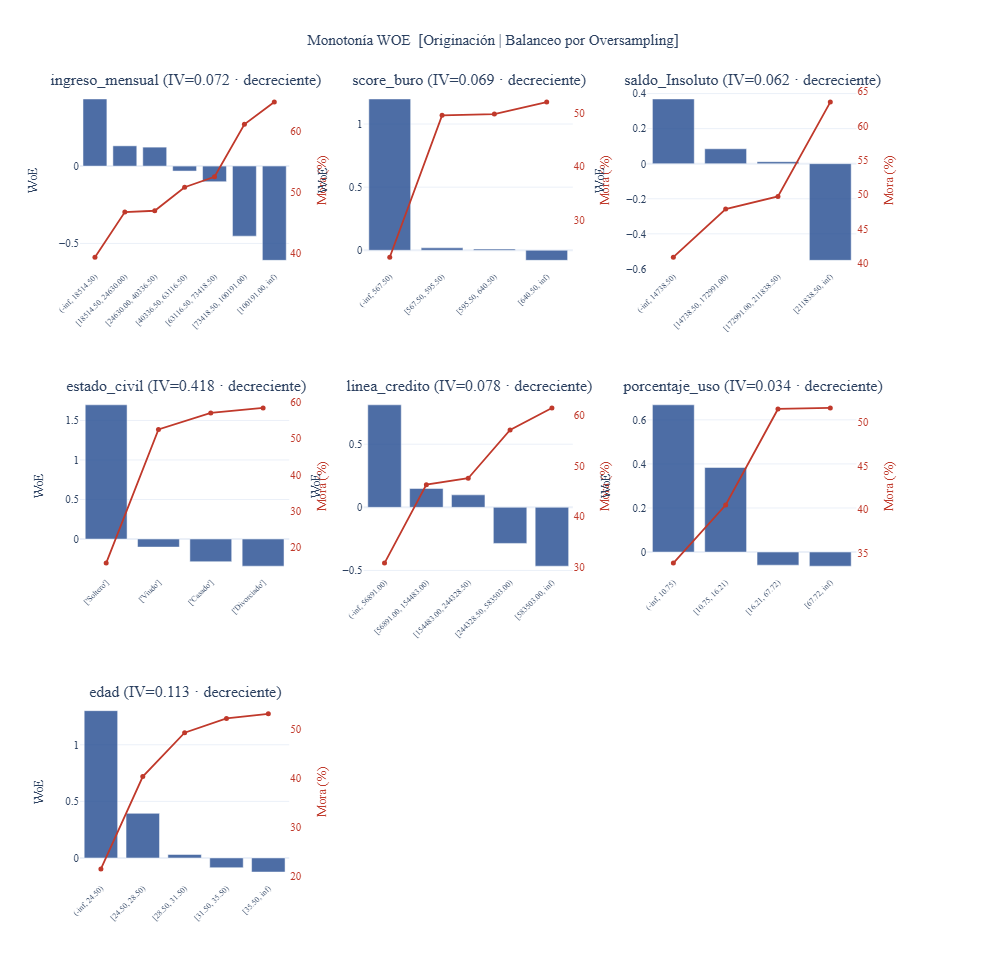

Monotonía e IV en Originación:


,Variable,Tramos,IV,Monotonía
0,ingreso_mensual,7,0.0719,decreciente
1,score_buro,4,0.0695,decreciente
2,saldo_Insoluto,4,0.0619,decreciente
3,estado_civil,4,0.4183,decreciente
4,linea_credito,5,0.0778,decreciente
5,porcentaje_uso,4,0.0336,decreciente
6,edad,5,0.1129,decreciente


In [10]:
bins_orig = ajustar_binning(train_bal[vars_sel], train_bal['Target'], vars_sel)
resumen_orig = graficar_monotonia(bins_orig, vars_sel, 'Monotonía WOE  [Originación | Balanceo por Oversampling]')
print('Monotonía e IV en Originación:')
resumen_orig

In [11]:
# Transformación a WoE de las 3 particiones
Xtr = transformar_woe(bins_orig, train_bal, vars_sel); ytr = train_bal['Target'].values
Xte = transformar_woe(bins_orig, test,      vars_sel); yte = test['Target'].values
Xoo = transformar_woe(bins_orig, oot,       vars_sel); yoo = oot['Target'].values
woe_features = list(Xtr.columns)
Xtr.head()

,ingreso_mensual_woe,score_buro_woe,saldo_Insoluto_woe,estado_civil_woe,linea_credito_woe,porcentaje_uso_woe,edad_woe
0,0.122426,-0.079849,0.085081,1.697702,-0.285926,-0.059460,-0.124311
1,-0.452980,-0.079849,0.085081,-0.286892,-0.285926,-0.059460,-0.124311
2,0.122426,1.198631,0.085081,-0.101882,-0.285926,-0.059460,-0.124311
3,0.433882,-0.079849,0.369206,-0.286892,0.811968,0.383866,1.301257
4,0.122426,0.009635,0.085081,-0.286892,0.098600,-0.059460,0.394225


### 3.5 Entrenamiento, validación cruzada y evaluación 

In [12]:
logit = LogisticRegression(solver='liblinear', random_state=semilla).fit(Xtr, ytr)

# Validación cruzada (estabilidad del AUC en el train balanceado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
auc_cv = cross_val_score(logit, Xtr, ytr, scoring='roc_auc', cv=cv)
print('AUC por fold:', np.round(auc_cv, 4), '\nAUC CV promedio:', round(auc_cv.mean(), 4))

AUC por fold: [0.7149 0.7029 0.7031 0.7112 0.7129] 
AUC CV promedio: 0.709


AUC TEST = 0.4999   |   AUC OOT = 0.4438

TEST
              precision    recall  f1-score   support

           0      0.994     0.499     0.664      3480
           1      0.006     0.500     0.011        20

    accuracy                          0.499      3500
   macro avg      0.500     0.499     0.338      3500
weighted avg      0.989     0.499     0.660      3500

OOT
              precision    recall  f1-score   support

           0      0.993     0.505     0.669      3479
           1      0.005     0.429     0.010        21

    accuracy                          0.504      3500
   macro avg      0.499     0.467     0.340      3500
weighted avg      0.987     0.504     0.665      3500



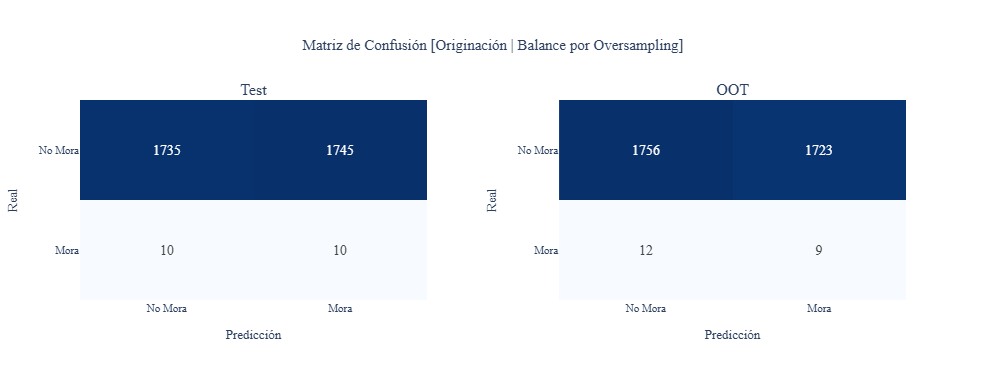

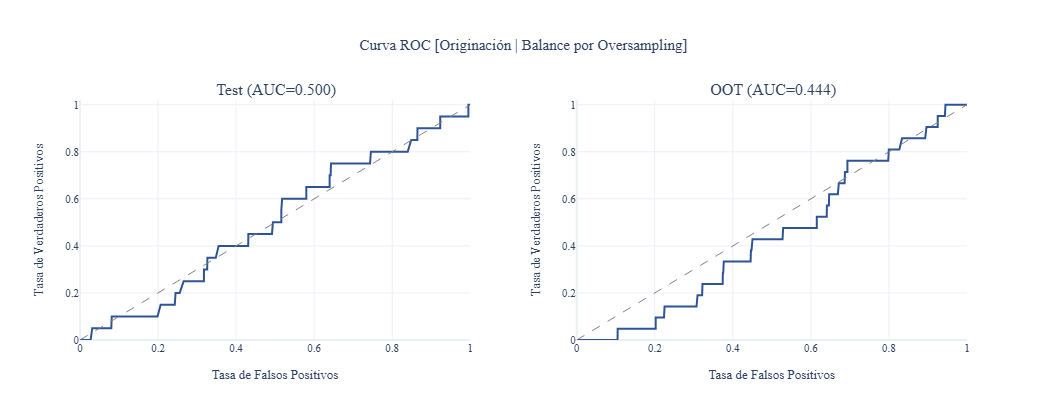

In [13]:
# Probabilidades y clases predichas
p_te, p_oo = logit.predict_proba(Xte)[:,1], logit.predict_proba(Xoo)[:,1]
evaluar('[Originación | Balance por Oversampling]',
        yte, p_te, logit.predict(Xte),
        yoo, p_oo, logit.predict(Xoo))

### 3.6 Estabilidad poblacional (PSI Train vs OOT)

In [14]:
psi_orig, tabla_psi_orig = calcular_psi(logit.predict_proba(Xtr)[:,1], p_oo)
print(f'PSI Train vs OOT = {psi_orig:.4f}  \t  {lectura_psi(psi_orig)}')
tabla_psi_orig.round(4)

PSI Train vs OOT = 0.1534  	  1 cambio moderado (0.10–0.25)


,bin_inf,bin_sup,pct_train,pct_oot,psi_bin
0,-inf,0.1608,0.0998,0.1943,0.0629
1,0.1608,0.2895,0.0990,0.1414,0.0151
2,0.2895,0.4572,0.1011,0.1171,0.0024
3,0.4572,0.5200,0.0999,0.0809,0.0040
4,0.5200,0.5560,0.0995,0.0966,0.0001
5,0.5560,0.5923,0.1002,0.0994,0.0000
6,0.5923,0.6113,0.1001,0.0777,0.0057
7,0.6113,0.6575,0.0856,0.0771,0.0009
8,0.6575,0.7187,0.1132,0.0649,0.0269
9,0.7187,inf,0.1015,0.0506,0.0354


### 3.7 Coeficientes de regresión y *scorecard*

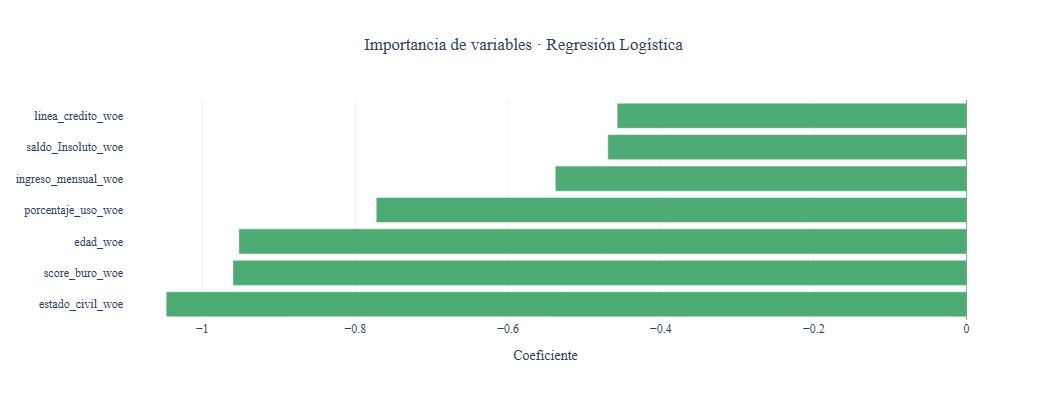

In [15]:
coef = (pd.DataFrame({'Variable': woe_features, 'Coeficiente': logit.coef_[0]})
        .sort_values('Coeficiente'))

colores = [rojo if c > 0 else verde for c in coef['Coeficiente']]
fig = go.Figure(go.Bar(x=coef['Coeficiente'], y=coef['Variable'], orientation='h',
                       marker_color=colores, opacity=.85))
fig.add_vline(x=0, line_color='grey', line_width=.8)
fig.update_layout(template='plotly_white', height=400, width=760,
                  title_text='Importancia de variables · Regresión Logística', title_x=0.5,
                  xaxis_title='Coeficiente', font=dict(family='serif', size=12))
fig.show()

In [16]:
# Estructura matemática final de la regresión logística — modelo principal
tabla_ec_orig = estructura_logistica(logit, woe_features, '— Originación (balance por Oversampling)')
tabla_ec_orig.round(4)

**Estructura matemática final — Regresión logística — Originación (balance por Oversampling)**  
Las variables explicativas son los WoE de cada predictor; intercepto $\beta_0=0.0025$, con $k=7$ términos.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Término,Coeficiente
0,Intercepto (β₀),0.0025
1,ingreso_mensual_woe,-0.5383
2,score_buro_woe,-0.9602
3,saldo_Insoluto_woe,-0.4695
4,estado_civil_woe,-1.0475
5,linea_credito_woe,-0.4574
6,porcentaje_uso_woe,-0.7726
7,edad_woe,-0.9524


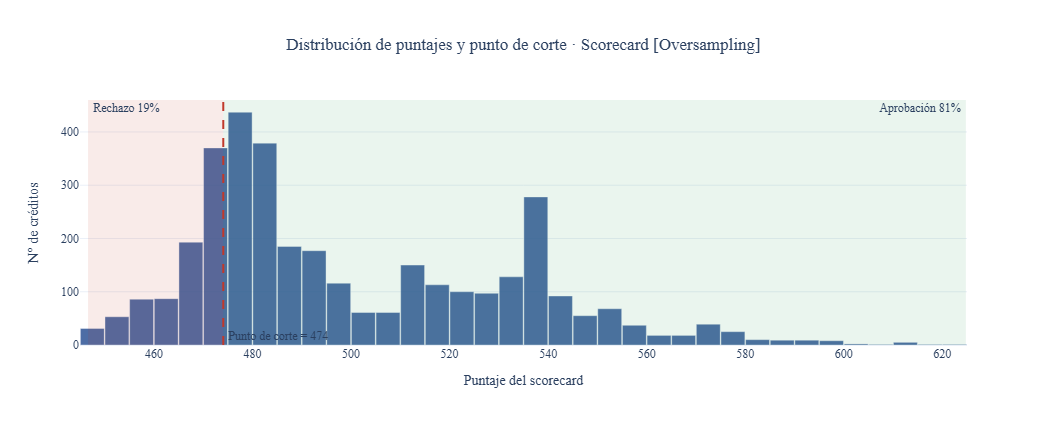

In [17]:
# Distribución de puntajes del scorecard y punto de corte — Originación [Oversampling]
_pdo, _base, _odds = 20, 600, 50
_factor = _pdo / np.log(2); _offset = _base - _factor * np.log(_odds)
TASA_APROBACION = 0.80   # tasa de aprobación objetivo que sitúa el punto de corte

sc_orig = puntaje_total(logit, Xoo, _factor, _offset)
cut_orig = np.quantile(sc_orig, 1 - TASA_APROBACION)
res_corte_orig = graficar_distribucion_cutoff(sc_orig, yoo, cut_orig,
    'Distribución de puntajes y punto de corte · Scorecard [Oversampling]')

### 3.8 Contraste: balanceo por percentiles sobre la variable dependiente

Técnica alternativa de balanceo (independiente del flujo principal sub/sobre-muestreo). 
La clase mayoritaria se submuestrea de forma estratificada por percentiles de la variable 
dependiente continua (`dias_atraso`); la minoritaria se conserva completa. Se repite todo 
el pipeline de originación (binning WoE → logística → evaluación → PSI → scorecard) sin 
alterar los objetos del modelo principal.

     percentiles efectivos = 7 | ratio = 1:1
     Distribución del train balanceado:
Target
0    63
1    63
Name: count, dtype: int64 



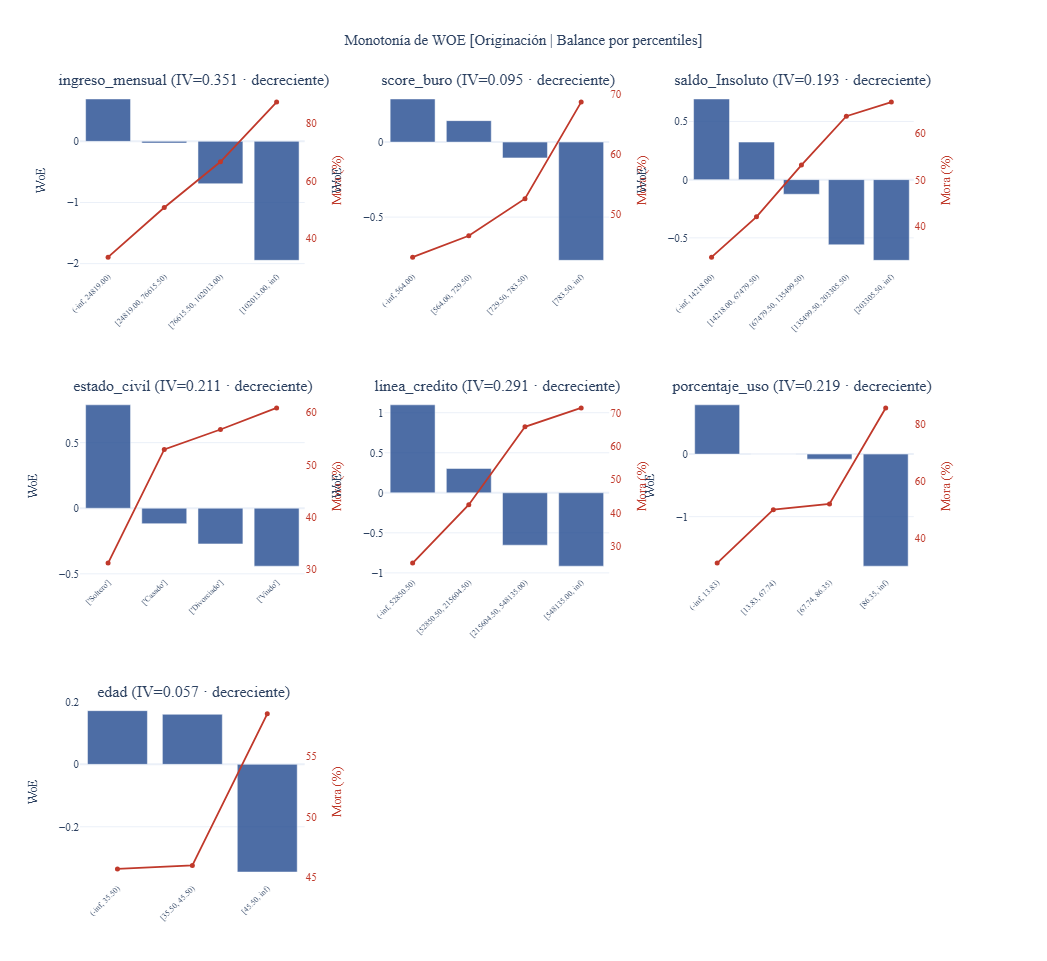

Monotonía e IV  [percentiles]:


,Variable,Tramos,IV,Monotonía
0,ingreso_mensual,4,0.3508,decreciente
1,score_buro,4,0.0950,decreciente
2,saldo_Insoluto,5,0.1926,decreciente
3,estado_civil,4,0.2106,decreciente
4,linea_credito,4,0.2910,decreciente
5,porcentaje_uso,4,0.2186,decreciente
6,edad,3,0.0567,decreciente


AUC por fold: [0.7101 0.6282 0.5897 0.8013 0.641 ] | AUC CV promedio: 0.6741 

AUC TEST = 0.4754   |   AUC OOT = 0.4631

TEST
              precision    recall  f1-score   support

           0      0.994     0.515     0.678      3480
           1      0.005     0.450     0.010        20

    accuracy                          0.515      3500
   macro avg      0.500     0.482     0.344      3500
weighted avg      0.988     0.515     0.675      3500

OOT
              precision    recall  f1-score   support

           0      0.992     0.521     0.683      3479
           1      0.004     0.333     0.008        21

    accuracy                          0.519      3500
   macro avg      0.498     0.427     0.346      3500
weighted avg      0.986     0.519     0.679      3500



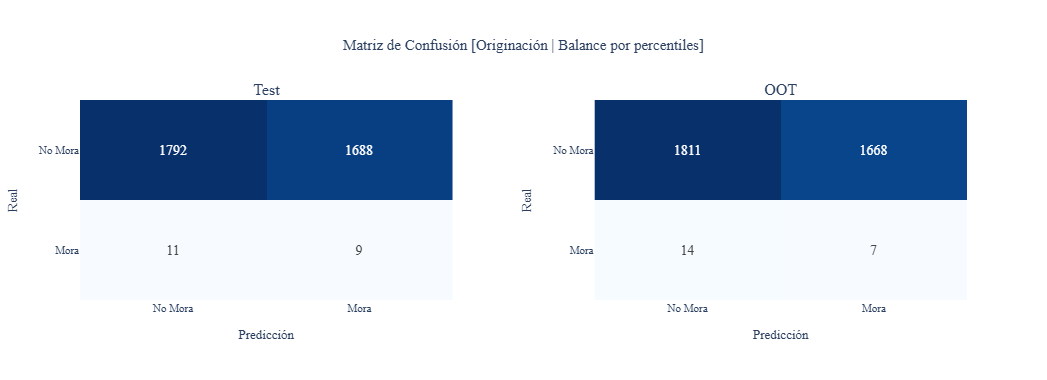

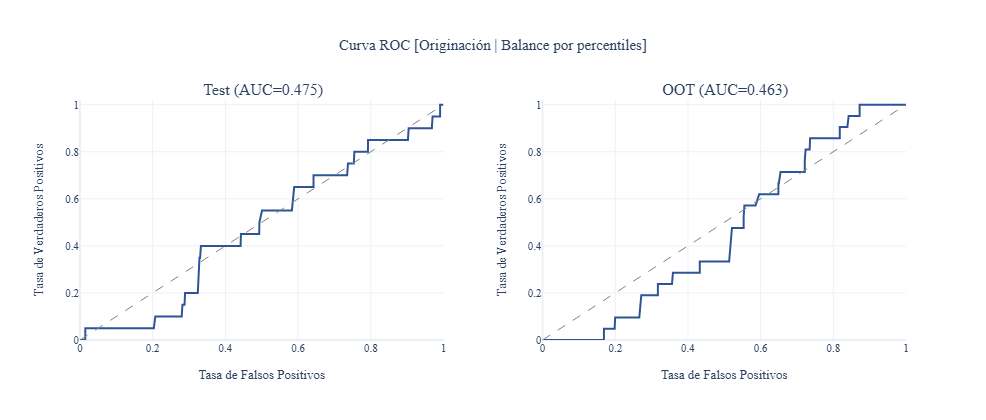

PSI Train vs OOT = 0.0701	 1 estable (<0.10)


,bin_inf,bin_sup,pct_train,pct_oot,psi_bin
0,-inf,0.2598,0.1032,0.0786,0.0067
1,0.2598,0.3223,0.0952,0.0786,0.0032
2,0.3223,0.4096,0.1032,0.1383,0.0103
3,0.4096,0.4658,0.0952,0.1446,0.0206
4,0.4658,0.4928,0.0952,0.0729,0.0060
5,0.4928,0.5341,0.1032,0.0863,0.0030
6,0.5341,0.5904,0.1032,0.1163,0.0016
7,0.5904,0.6502,0.0952,0.1114,0.0025
8,0.6502,0.7111,0.1032,0.0666,0.0160
9,0.7111,inf,0.1032,0.1066,0.0001


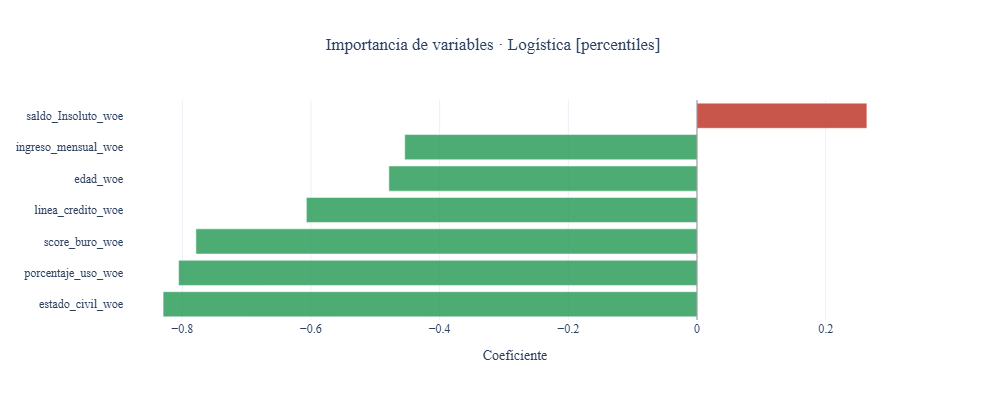

Scorecard [percentiles]:


,Variable,Tramo,WoE,Puntos
0,ingreso_mensual,"(-inf, 24819.00)",0.6931,79
1,ingreso_mensual,"[24819.00, 76615.50)",-0.0274,69
2,ingreso_mensual,"[76615.50, 102013.00)",-0.6931,61
3,ingreso_mensual,"[102013.00, inf)",-1.9459,44
4,score_buro,"(-inf, 564.00)",0.2877,76
5,score_buro,"[564.00, 729.50)",0.1431,73
6,score_buro,"[729.50, 783.50)",-0.1054,67
7,score_buro,"[783.50, inf)",-0.7885,52
8,saldo_Insoluto,"(-inf, 14218.00)",0.6931,64
9,saldo_Insoluto,"[14218.00, 67479.50)",0.3228,67



Contraste de AUC (Test / OOT):
Modelo 1 por sub/sobre-muestreo:  0.4999 / 0.4438
Modelo 2 por Percentiles:  0.4754 / 0.4631


In [18]:
# Contraste al sobremuestro por percentiles

q_pct, ratio_pct = 10, 1.0      # percentiles (deciles)

# 2.8.1  Balanceo por percentiles 
maj  = train[train['Target'] == 0].copy()
minr = train[train['Target'] == 1].copy()
n_obj = int(len(minr) * ratio_pct)

maj['_pctl'] = pd.qcut(maj['dias_atraso'], q=q_pct, duplicates='drop')
grupos = maj.groupby('_pctl', observed=True)
n_bins = grupos.ngroups
base, resto = divmod(n_obj, n_bins)                       # reparto equiprobable por percentil

partes = []
for i, (_, g) in enumerate(grupos):
    k = base + (1 if i < resto else 0)
    partes.append(g.sample(min(len(g), k), random_state=semilla))
maj_bal = pd.concat(partes).drop(columns='_pctl')

train_bal_pct = (pd.concat([maj_bal, minr])
                 .sample(frac=1, random_state=semilla).reset_index(drop=True))
print(f'     percentiles efectivos = {n_bins} | ratio = {ratio_pct:g}:1')
print('     Distribución del train balanceado:')
print(train_bal_pct['Target'].value_counts(), '\n')

# 2.8.2  Binning, WoE monótono
bins_pct = ajustar_binning(train_bal_pct[vars_sel], train_bal_pct['Target'], vars_sel)
resumen_pct = graficar_monotonia(bins_pct, vars_sel,
                                  'Monotonía de WOE [Originación | Balance por percentiles]')
print('Monotonía e IV  [percentiles]:'); display(resumen_pct)

# 2.8.3  Transformación a WoE de las 3 particiones 
Xtr_pct = transformar_woe(bins_pct, train_bal_pct, vars_sel); ytr_pct = train_bal_pct['Target'].values
Xte_pct = transformar_woe(bins_pct, test,          vars_sel); yte_pct = test['Target'].values
Xoo_pct = transformar_woe(bins_pct, oot,           vars_sel); yoo_pct = oot['Target'].values
woe_features_pct = list(Xtr_pct.columns)
Xtr_pct.head()

#  2.8.4  Entrenamiento, validación cruzada y evaluación 
logit_pct = LogisticRegression(solver='liblinear', random_state=semilla).fit(Xtr_pct, ytr_pct)
cv_pct = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
auc_cv_pct = cross_val_score(logit_pct, Xtr_pct, ytr_pct, scoring='roc_auc', cv=cv_pct)
print('AUC por fold:', np.round(auc_cv_pct, 4), '| AUC CV promedio:', round(auc_cv_pct.mean(), 4), '\n')

p_te_pct = logit_pct.predict_proba(Xte_pct)[:, 1]
p_oo_pct = logit_pct.predict_proba(Xoo_pct)[:, 1]
evaluar('[Originación | Balance por percentiles]',
        yte_pct, p_te_pct, logit_pct.predict(Xte_pct),
        yoo_pct, p_oo_pct, logit_pct.predict(Xoo_pct))

# 2.8.5  Estabilidad poblacional (PSI Train vs OOT)
psi_pct, tabla_psi_pct = calcular_psi(logit_pct.predict_proba(Xtr_pct)[:, 1], p_oo_pct)
print(f'PSI Train vs OOT = {psi_pct:.4f}\t {lectura_psi(psi_pct)}')
display(tabla_psi_pct.round(4))

# 2.8.6  Coeficientes y scorecard 
coef_pct = (pd.DataFrame({'Variable': woe_features_pct, 'Coeficiente': logit_pct.coef_[0]})
            .sort_values('Coeficiente'))
fig = go.Figure(go.Bar(x=coef_pct['Coeficiente'], y=coef_pct['Variable'], orientation='h',
                       marker_color=[rojo if c > 0 else verde for c in coef_pct['Coeficiente']], opacity=.85))
fig.add_vline(x=0, line_color='grey', line_width=.8)
fig.update_layout(template='plotly_white', height=400, width=760,
                  title_text='Importancia de variables · Logística [percentiles]', title_x=0.5,
                  xaxis_title='Coeficiente', font=dict(family='serif', size=12))
fig.show()

pdo, Score_base, Odds_base = 20, 600, 50
factor = pdo / np.log(2); offset = Score_base - factor * np.log(Odds_base)
intercepto_pct, k_pct = logit_pct.intercept_[0], len(woe_features_pct)
filas = []
for var, beta in zip(vars_sel, logit_pct.coef_[0]):
    for _, r in _bins_reales(bins_pct[var]).iterrows():
        puntos = -(beta * r['WoE'] + intercepto_pct / k_pct) * factor + offset / k_pct
        filas.append({'Variable': var, 'Tramo': r['Bin'], 'WoE': round(r['WoE'], 4), 'Puntos': round(puntos)})
scorecard_pct = pd.DataFrame(filas)
print('Scorecard [percentiles]:'); display(scorecard_pct.head(50))

# 2.8.7  Contraste de AUC vs. modelo con sobremuestreo
try:
    print('\nContraste de AUC (Test / OOT):')
    print(f'Modelo 1 por sub/sobre-muestreo:  {roc_auc_score(yte, p_te):.4f} / {roc_auc_score(yoo, p_oo):.4f}')
    print(f'Modelo 2 por Percentiles:  {roc_auc_score(yte_pct, p_te_pct):.4f} / {roc_auc_score(yoo_pct, p_oo_pct):.4f}')
except NameError:
    print('\n(Corre antes la sección 2 para ver el contraste de AUC con el modelo principal.)')

In [19]:
# Estructura matemática final de la regresión logística — balanceo por percentiles
tabla_ec_pct = estructura_logistica(logit_pct, woe_features_pct, '— Originación · percentiles')
tabla_ec_pct.round(4)

**Estructura matemática final — Regresión logística — Originación · percentiles**  
Las variables explicativas son los WoE de cada predictor; intercepto $\beta_0=-0.0023$, con $k=7$ términos.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Término,Coeficiente
0,Intercepto (β₀),-0.0023
1,ingreso_mensual_woe,-0.4543
2,score_buro_woe,-0.7788
3,saldo_Insoluto_woe,0.2641
4,estado_civil_woe,-0.8298
5,linea_credito_woe,-0.6072
6,porcentaje_uso_woe,-0.8058
7,edad_woe,-0.4789


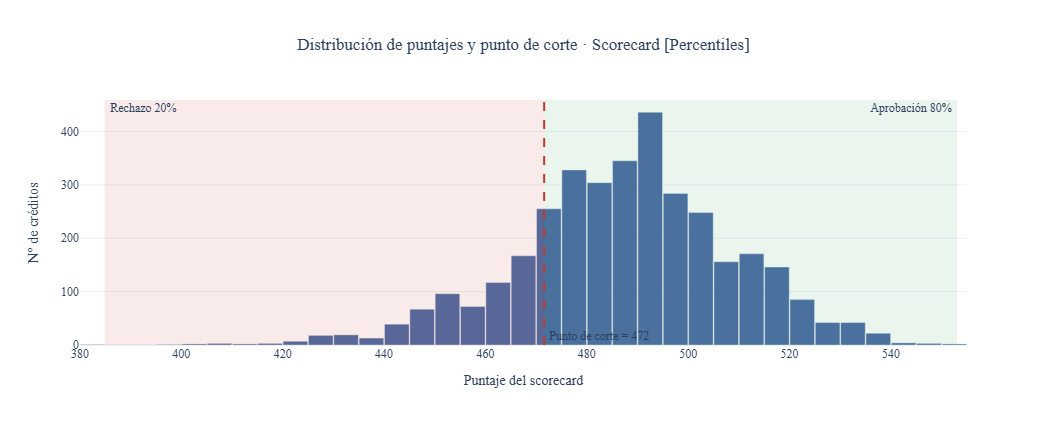

In [20]:
# Distribución de puntajes del scorecard y punto de corte — Originación [Percentiles]
_pdo, _base, _odds = 20, 600, 50
_factor = _pdo / np.log(2); _offset = _base - _factor * np.log(_odds)
sc_pct = puntaje_total(logit_pct, Xoo_pct, _factor, _offset)
cut_pct = np.quantile(sc_pct, 1 - TASA_APROBACION)
res_corte_pct = graficar_distribucion_cutoff(sc_pct, yoo_pct, cut_pct,
    'Distribución de puntajes y punto de corte · Scorecard [Percentiles]')

### 3.9 Balance de clases mediante Class Weight

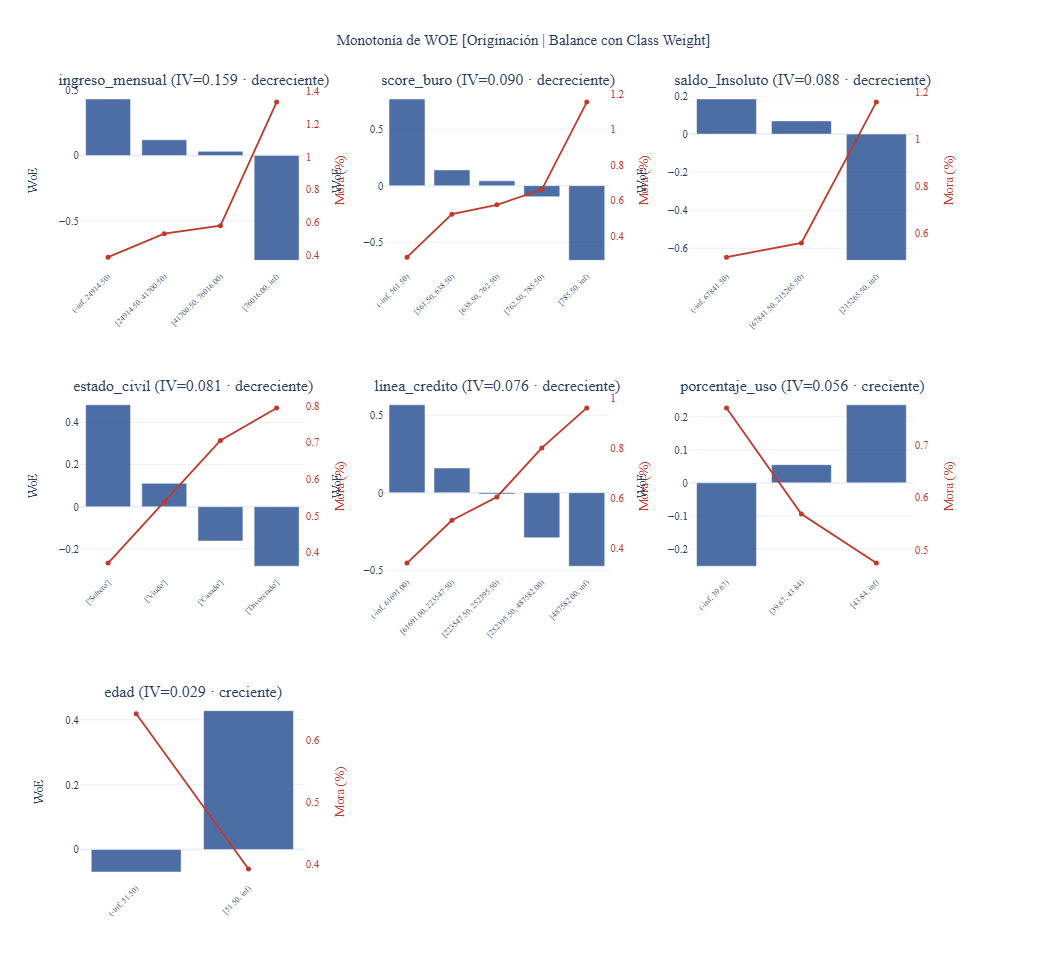

Monotonía e IV [class_weight]:


,Variable,Tramos,IV,Monotonía
0,ingreso_mensual,4,0.1586,decreciente
1,score_buro,5,0.0895,decreciente
2,saldo_Insoluto,3,0.0882,decreciente
3,estado_civil,4,0.0807,decreciente
4,linea_credito,5,0.0756,decreciente
5,porcentaje_uso,3,0.0565,creciente
6,edad,2,0.0295,creciente


AUC por fold: [0.6447 0.5811 0.7485 0.5268 0.7171] | AUC promedio: 0.6436

AUC TEST = 0.4437   |   AUC OOT = 0.5659

TEST
              precision    recall  f1-score   support

           0      0.994     0.647     0.784      3480
           1      0.006     0.350     0.011        20

    accuracy                          0.645      3500
   macro avg      0.500     0.499     0.398      3500
weighted avg      0.989     0.645     0.780      3500

OOT
              precision    recall  f1-score   support

           0      0.996     0.642     0.780      3479
           1      0.009     0.524     0.017        21

    accuracy                          0.641      3500
   macro avg      0.502     0.583     0.399      3500
weighted avg      0.990     0.641     0.776      3500



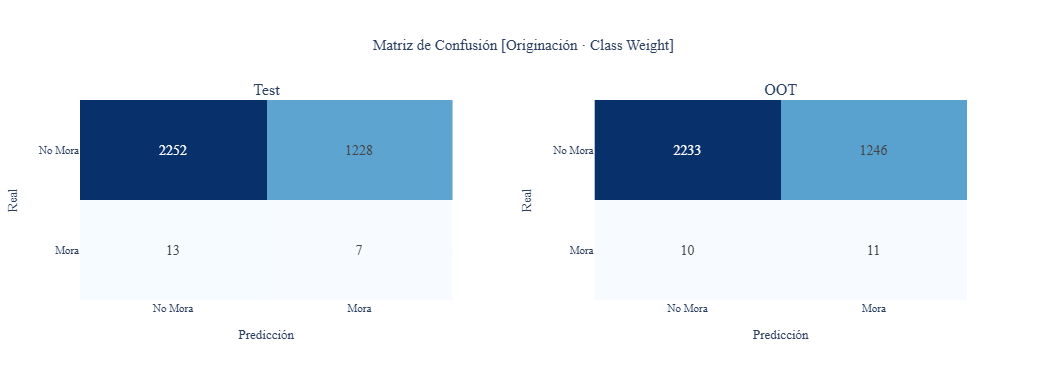

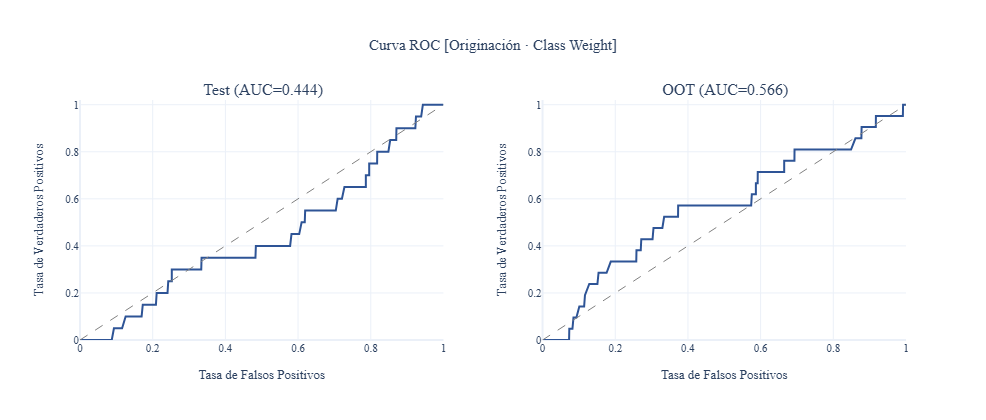

PSI Train vs OOT = 0.0021	1 estable (<0.10)


,bin_inf,bin_sup,pct_train,pct_oot,psi_bin
0,-inf,0.2346,0.0994,0.1094,0.0010
1,0.2346,0.2985,0.1004,0.1046,0.0002
2,0.2985,0.3505,0.0985,0.0940,0.0002
3,0.3505,0.3940,0.1006,0.0983,0.0001
4,0.3940,0.4302,0.1011,0.1006,0.0000
5,0.4302,0.4763,0.0950,0.0909,0.0002
6,0.4763,0.5296,0.1048,0.1051,0.0000
7,0.5296,0.5918,0.1002,0.0949,0.0003
8,0.5918,0.6516,0.0998,0.0974,0.0001
9,0.6516,inf,0.1002,0.1049,0.0002


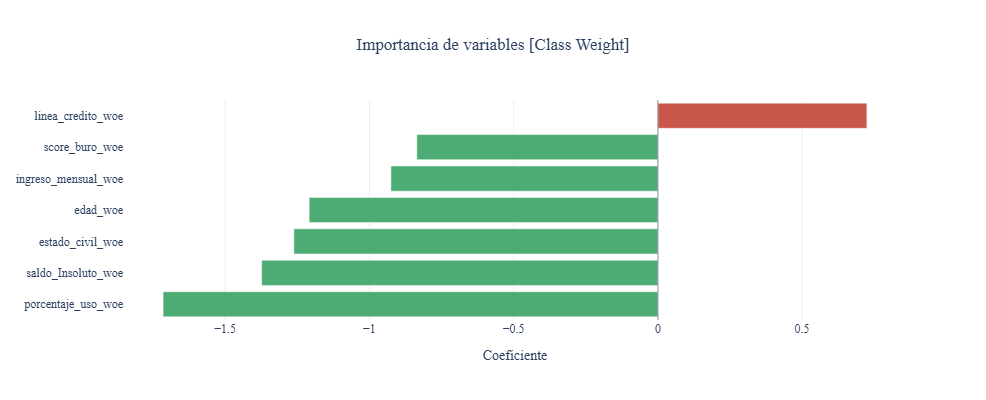

Scorecard [Class Weight]


,Variable,Tramo,WoE,Puntos
0,ingreso_mensual,"(-inf, 24914.50)",0.4334,81
1,ingreso_mensual,"[24914.50, 41700.50)",0.1199,73
2,ingreso_mensual,"[41700.50, 76016.00)",0.0317,70
3,ingreso_mensual,"[76016.00, inf)",-0.8042,48
4,score_buro,"(-inf, 561.50)",0.7664,88
5,score_buro,"[561.50, 638.50)",0.1395,73
6,score_buro,"[638.50, 762.50)",0.0426,71
7,score_buro,"[762.50, 785.50)",-0.0977,67
8,score_buro,"[785.50, inf)",-0.6599,54
9,saldo_Insoluto,"(-inf, 67841.50)",0.1845,77



Comparación final
-------------------------------------------------------
SMOTE      Test/OOT: 0.4999 / 0.4438
ClassWeight Test/OOT: 0.4437 / 0.5659

Diferencia AUC:
Test: -0.0562
OOT: 0.1221


In [21]:
# 2.9.1 WOE monotónico 
bins_cw = ajustar_binning(train[vars_sel], train['Target'], vars_sel)
resumen_cw = graficar_monotonia(bins_cw, vars_sel, 'Monotonía de WOE [Originación | Balance con Class Weight]')
print('Monotonía e IV [class_weight]:'); display(resumen_cw)

# 2.9.2 Transformación WoE 
Xtr_cw, ytr_cw = transformar_woe(bins_cw, train, vars_sel), train['Target'].values
Xte_cw, yte_cw = transformar_woe(bins_cw, test, vars_sel), test['Target'].values
Xoo_cw, yoo_cw = transformar_woe(bins_cw, oot, vars_sel), oot['Target'].values
woe_features_cw = list(Xtr_cw.columns)

#2.9.3 Entrenamiento y validación cruzada 
logit_cw = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=semilla)
logit_cw.fit(Xtr_cw, ytr_cw)
cv_cw = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
auc_cv_cw = cross_val_score(logit_cw, Xtr_cw, ytr_cw, scoring='roc_auc', cv=cv_cw)
print(f'AUC por fold: {np.round(auc_cv_cw,4)} | AUC promedio: {round(auc_cv_cw.mean(),4)}\n')

# 2.9.4 Evaluación 
p_te_cw, p_oo_cw = logit_cw.predict_proba(Xte_cw)[:,1], logit_cw.predict_proba(Xoo_cw)[:,1]
evaluar('[Originación · Class Weight]', yte_cw, p_te_cw, logit_cw.predict(Xte_cw), yoo_cw, p_oo_cw, logit_cw.predict(Xoo_cw))

# 2.9.5 PSI 
psi_cw, tabla_psi_cw = calcular_psi(logit_cw.predict_proba(Xtr_cw)[:,1], p_oo_cw)
print(f'PSI Train vs OOT = {psi_cw:.4f}\t{lectura_psi(psi_cw)}'); display(tabla_psi_cw.round(4))

# 2.9.6 Coeficientes 
coef_cw = pd.DataFrame({'Variable':woe_features_cw, 'Coeficiente':logit_cw.coef_[0]}).sort_values('Coeficiente')
fig = go.Figure(go.Bar(x=coef_cw['Coeficiente'], y=coef_cw['Variable'], orientation='h',
                       marker_color=[rojo if c>0 else verde for c in coef_cw['Coeficiente']], opacity=.85))
fig.add_vline(x=0, line_color='grey', line_width=.8)
fig.update_layout(template='plotly_white', height=400, width=760,
                  title_text='Importancia de variables [Class Weight]', title_x=0.5,
                  xaxis_title='Coeficiente', font=dict(family='serif', size=12))
fig.show()

# 2.9.7 Scorecard 
pdo, Score_base, Odds_base = 20, 600, 50
factor, offset = pdo/np.log(2), Score_base - (pdo/np.log(2))*np.log(Odds_base)
intercepto_cw, k_cw = logit_cw.intercept_[0], len(woe_features_cw)
filas = []
for var, beta in zip(vars_sel, logit_cw.coef_[0]):
    for _, r in _bins_reales(bins_cw[var]).iterrows():
        puntos = -(beta * r['WoE'] + intercepto_cw/k_cw) * factor + offset/k_cw
        filas.append({'Variable':var, 'Tramo':r['Bin'], 'WoE':round(r['WoE'],4), 'Puntos':round(puntos)})
scorecard_cw = pd.DataFrame(filas)
print('Scorecard [Class Weight]'); display(scorecard_cw.head(50))

# 2.9.8 Comparación SMOTE vs Class Weight 
auc_te, auc_oo = roc_auc_score(yte, p_te), roc_auc_score(yoo, p_oo)
auc_te_cw, auc_oo_cw = roc_auc_score(yte_cw, p_te_cw), roc_auc_score(yoo_cw, p_oo_cw)
print(f'\nComparación final\n{"-"*55}\nSMOTE      Test/OOT: {auc_te:.4f} / {auc_oo:.4f}')
print(f'ClassWeight Test/OOT: {auc_te_cw:.4f} / {auc_oo_cw:.4f}\n\nDiferencia AUC:')
print(f'Test: {(auc_te_cw - auc_te):.4f}\nOOT: {(auc_oo_cw - auc_oo):.4f}')

In [22]:
# Estructura matemática final de la regresión logística — class_weight='balanced'
tabla_ec_cw = estructura_logistica(logit_cw, woe_features_cw, '— Originación · class_weight')
tabla_ec_cw.round(4)

**Estructura matemática final — Regresión logística — Originación · class_weight**  
Las variables explicativas son los WoE de cada predictor; intercepto $\beta_0=-0.0036$, con $k=7$ términos.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Término,Coeficiente
0,Intercepto (β₀),-0.0036
1,ingreso_mensual_woe,-0.9257
2,score_buro_woe,-0.8357
3,saldo_Insoluto_woe,-1.3738
4,estado_civil_woe,-1.2621
5,linea_credito_woe,0.7247
6,porcentaje_uso_woe,-1.7155
7,edad_woe,-1.2091


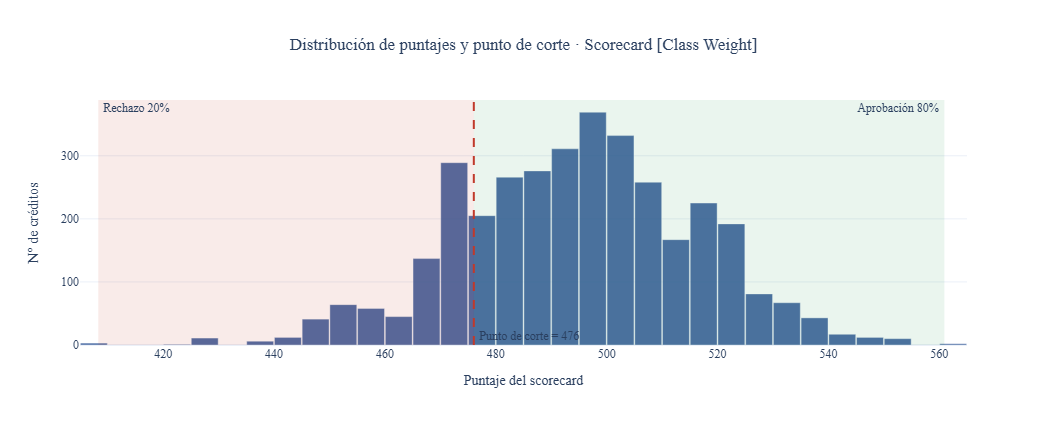

In [23]:
# Distribución de puntajes del scorecard y punto de corte — Originación [Class Weight]
_pdo, _base, _odds = 20, 600, 50
_factor = _pdo / np.log(2); _offset = _base - _factor * np.log(_odds)
sc_cw = puntaje_total(logit_cw, Xoo_cw, _factor, _offset)
cut_cw = np.quantile(sc_cw, 1 - TASA_APROBACION)
res_corte_cw = graficar_distribucion_cutoff(sc_cw, yoo_cw, cut_cw,
    'Distribución de puntajes y punto de corte · Scorecard [Class Weight]')

### 3.10 Modelo de originación — punto de corte, política de aceptación y segmentación del riesgo


Punto de corte (rechazo) = 476  |  corte alto (revisión→aprobar) = 484

Política de aceptación  (PD y tasa de mora en %):


,Creditos,PD_promedio,Tasa_mora,% poblacion
Decisión,,,,
Aprobar,12265,35.86,0.42,70.09
Revisión manual,1735,56.09,0.81,9.91
Rechazar,3500,67.64,1.11,20.00



Segmentación del riesgo por grado (quintiles de score):


,Creditos,Score_min,Score_max,PD_promedio,Tasa_mora,% poblacion,Tratamiento
Grado,,,,,,,
E (mayor riesgo),3500,408.0,476.0,67.64,1.11,20.0,Rechazo o exigencia de garantía adicional
D,3500,476.0,490.0,53.14,0.66,20.0,"Línea baja, precio alto, revisión manual"
C,3500,490.0,500.0,43.05,0.43,20.0,"Línea moderada, precio con recargo, aprobación..."
B,3500,500.0,513.0,34.69,0.43,20.0,"Línea estándar, precio estándar, aprobación au..."
A (menor riesgo),3500,513.0,565.0,22.58,0.34,20.0,"Línea amplia, precio preferente, aprobación au..."


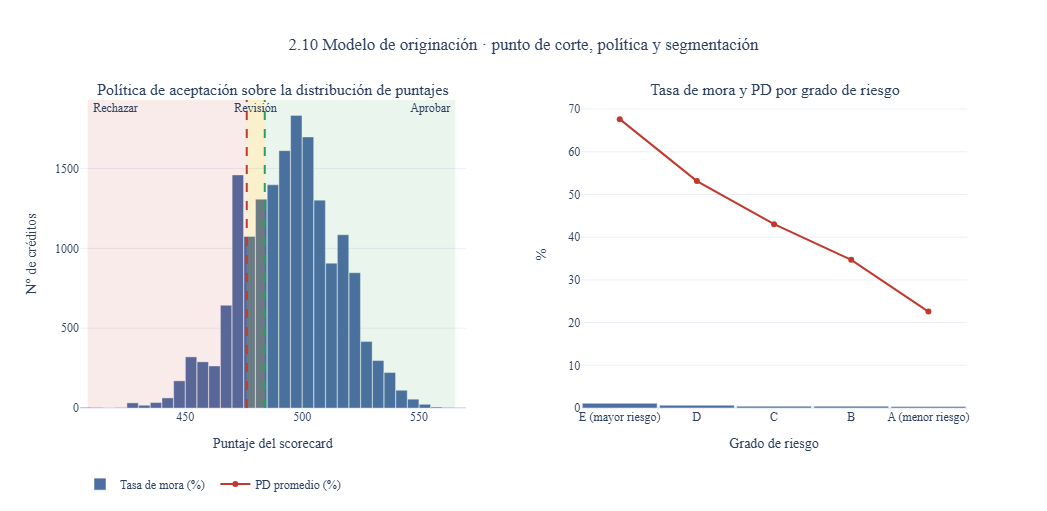

In [24]:
    # Puntaje y PD de cada crédito sobre toda la cartera
    pdo_o, base_o, odds_o = 20, 600, 50
    factor_o = pdo_o / np.log(2); offset_o = base_o - factor_o * np.log(odds_o)
    
    X_pob = pd.concat([Xtr_cw, Xte_cw, Xoo_cw])
    y_pob = np.concatenate([ytr_cw, yte_cw, yoo_cw])
    score_pob = offset_o - factor_o * logit_cw.decision_function(X_pob)
    pd_pob = logit_cw.predict_proba(X_pob)[:, 1]
    pob = pd.DataFrame({'Score': score_pob, 'PD': pd_pob, 'Target': y_pob})
    
    # Cutoff: tasa de aprobación objetivo + banda de revisión 
    TASA_APROBACION_OBJ = 0.80      # se aprueba aproximadamente el mejor 80%
    BANDA_REVISION      = 0.10      # 10% por encima del corte va a revisión manual
    corte_rechazo = np.quantile(pob['Score'], 1 - TASA_APROBACION_OBJ)
    corte_alto    = np.quantile(pob['Score'], 1 - TASA_APROBACION_OBJ + BANDA_REVISION)
    
    # Política de aceptación
    def _decision(s):
        if s < corte_rechazo: return 'Rechazar'
        if s < corte_alto:    return 'Revisión manual'
        return 'Aprobar'
    pob['Decisión'] = pob['Score'].apply(_decision)
    
    politica = (pob.groupby('Decisión')
                .agg(Creditos=('Target', 'size'), PD_promedio=('PD', 'mean'), Tasa_mora=('Target', 'mean'))
                .reindex(['Aprobar', 'Revisión manual', 'Rechazar']))
    politica['% poblacion'] = (politica['Creditos'] / len(pob) * 100).round(2)
    politica['PD_promedio'] = (politica['PD_promedio'] * 100).round(2)
    politica['Tasa_mora']   = (politica['Tasa_mora'] * 100).round(2)
    print(f'Punto de corte (rechazo) = {corte_rechazo:.0f}  |  corte alto (revisión→aprobar) = {corte_alto:.0f}')
    print('\nPolítica de aceptación  (PD y tasa de mora en %):'); display(politica)
    
    # Segmentación del riesgo: grados A–E por quintiles de score
    grados = ['E (mayor riesgo)', 'D', 'C', 'B', 'A (menor riesgo)']
    pob['Grado'] = pd.qcut(pob['Score'].rank(method='first'), q=5, labels=grados)
    tratamiento = {'A (menor riesgo)': 'Línea amplia, precio preferente, aprobación automática',
                   'B': 'Línea estándar, precio estándar, aprobación automática',
                   'C': 'Línea moderada, precio con recargo, aprobación condicionada',
                   'D': 'Línea baja, precio alto, revisión manual',
                   'E (mayor riesgo)': 'Rechazo o exigencia de garantía adicional'}
    segmentacion = (pob.groupby('Grado', observed=True)
                    .agg(Creditos=('Target', 'size'), Score_min=('Score', 'min'), Score_max=('Score', 'max'),
                         PD_promedio=('PD', 'mean'), Tasa_mora=('Target', 'mean'))
                    .reindex(grados))
    segmentacion['% poblacion'] = (segmentacion['Creditos'] / len(pob) * 100).round(2)
    segmentacion['PD_promedio'] = (segmentacion['PD_promedio'] * 100).round(2)
    segmentacion['Tasa_mora']   = (segmentacion['Tasa_mora'] * 100).round(2)
    segmentacion[['Score_min', 'Score_max']] = segmentacion[['Score_min', 'Score_max']].round(0)
    segmentacion['Tratamiento'] = [tratamiento[g] for g in segmentacion.index]
    print('\nSegmentación del riesgo por grado (quintiles de score):'); display(segmentacion)
    
    # Visualización 
    fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.13,
                        subplot_titles=('Política de aceptación sobre la distribución de puntajes',
                                        'Tasa de mora y PD por grado de riesgo'))
    fig.add_trace(go.Histogram(x=pob['Score'], nbinsx=45, marker_color='#2E5496',
                               marker_line_color='white', marker_line_width=.4, opacity=.85,
                               showlegend=False), row=1, col=1)
    fig.add_vrect(x0=float(pob['Score'].min()), x1=corte_rechazo, fillcolor=rojo, opacity=.10, line_width=0,
                  annotation_text='Rechazar', annotation_position='top left', row=1, col=1)
    fig.add_vrect(x0=corte_rechazo, x1=corte_alto, fillcolor=amarillo, opacity=.20, line_width=0,
                  annotation_text='Revisión', annotation_position='top', row=1, col=1)
    fig.add_vrect(x0=corte_alto, x1=float(pob['Score'].max()), fillcolor=verde, opacity=.10, line_width=0,
                  annotation_text='Aprobar', annotation_position='top right', row=1, col=1)
    fig.add_vline(x=corte_rechazo, line_color=rojo, line_width=2, line_dash='dash', row=1, col=1)
    fig.add_vline(x=corte_alto, line_color=verde, line_width=2, line_dash='dash', row=1, col=1)
    fig.update_xaxes(title_text='Puntaje del scorecard', row=1, col=1)
    fig.update_yaxes(title_text='N° de créditos', row=1, col=1)
    fig.add_trace(go.Bar(x=grados, y=segmentacion['Tasa_mora'], marker_color='#2E5496', opacity=.85,
                         name='Tasa de mora (%)'), row=1, col=2)
    fig.add_trace(go.Scatter(x=grados, y=segmentacion['PD_promedio'], mode='lines+markers',
                             line=dict(color=rojo, width=2), name='PD promedio (%)'), row=1, col=2)
    fig.update_xaxes(title_text='Grado de riesgo', row=1, col=2)
    fig.update_yaxes(title_text='%', row=1, col=2)
    fig.update_layout(template='plotly_white', height=450, width=1050, bargap=.03,
                      title_text='2.10 Modelo de originación · punto de corte, política y segmentación',
                      title_x=0.5, font=dict(family='serif', size=12), legend=dict(orientation='h', y=-0.2))
    fig.show()

## 4. Modelo de Cobranza
La variable objetivo se construyó explícitamente mediante el siguiente score híbrido de riesgo:

$$
Score_{Cobranza}
=
0.45 \cdot Score_{Dias}
+
0.35 \cdot Score_{Atrasos}
+
0.15 \cdot Score_{Minimo}
+
0.05 \cdot Proxy_{Garantia}
$$

donde:

- $Score_{Dias}$ representa la severidad de mora según `dias_atraso`,
- $Score_{Atrasos}$ representa la frecuencia de incumplimiento mediante `porcentaje_atrasos`,
- $Score_{Minimo}$ representa el estrés financiero usando `porcentaje_pago_minimo`,
- $Proxy_{Garantia}$ corresponde a `FLAG_GARANTÍAS` como variable proxy de deterioro.

Posteriormente, el score se transformó en una variable objetivo ordinal multiclase (`nivel_riesgo`) mediante:

$$
Nivel_{Riesgo}
=
\begin{cases}
0 \; (Verde), & Score_{Cobranza} \leq 0.60 \\[6pt]
1 \; (Amarillo), & 0.60 < Score_{Cobranza} \leq 1.30 \\[6pt]
2 \; (Rojo), & Score_{Cobranza} > 1.30
\end{cases}
$$

La variable objetivo quedó definida de la siguiente manera:

| Valor | Semáforo | Nivel |
|---|---|---|
| 0 | Verde | Bajo riesgo |
| 1 | Amarillo | Riesgo medio |
| 2 | Rojo | Alto riesgo |


In [25]:
# Configuración y preparación de datos
COD_RIESGO, NOM_RIESGO = {'Verde': 0, 'Amarillo': 1, 'Rojo': 2}, {0: 'Verde', 1: 'Amarillo', 2: 'Rojo'}
vars_cob = ['porcentaje_pago_minimo', 'porcentaje_pago_total', 'porcentaje_atrasos', 'porcentaje_saldo_financiado', 'porcentaje_credito_utilizado', 'porcentaje_uso', 'saldo_Insoluto', 'FLAG_GARANTÍAS']
vars_target = ['dias_atraso', 'porcentaje_atrasos', 'porcentaje_pago_minimo', 'FLAG_GARANTÍAS']

for c in vars_cob + vars_target: df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=list(set(vars_cob + vars_target))).reset_index(drop=True)

# Cálculo de scores por dimensión
score_dias = np.select([df['dias_atraso'] <= 15, (df['dias_atraso'] > 15) & (df['dias_atraso'] <= 60), df['dias_atraso'] > 60], [0, 1, 2])
score_atrasos = np.select([df['porcentaje_atrasos'] <= 10, (df['porcentaje_atrasos'] > 10) & (df['porcentaje_atrasos'] <= 35), df['porcentaje_atrasos'] > 35], [0, 1, 2])
score_minimo = np.select([df['porcentaje_pago_minimo'] <= 30, (df['porcentaje_pago_minimo'] > 30) & (df['porcentaje_pago_minimo'] <= 70), df['porcentaje_pago_minimo'] > 70], [0, 1, 2])
proxy_garantia = np.where(df['FLAG_GARANTÍAS'] == 1, 1, 0)

# Construcción de target final mediante ponderación
df['score_cobranza'] = 0.45 * score_dias + 0.35 * score_atrasos + 0.15 * score_minimo + 0.05 * proxy_garantia
df['nivel_riesgo'] = np.select([df['score_cobranza'] <= 0.60, (df['score_cobranza'] > 0.60) & (df['score_cobranza'] <= 1.30), df['score_cobranza'] > 1.30], [0, 1, 2])

# Partición estratificada del conjunto de datos
from sklearn.model_selection import train_test_split
Xc_tr, Xc_tmp, yc_tr, yc_tmp = train_test_split(df[vars_cob], df['nivel_riesgo'], train_size=.60, stratify=df['nivel_riesgo'], random_state=semilla)
Xc_te, Xc_oo, yc_te, yc_oo = train_test_split(Xc_tmp, yc_tmp, test_size=.50, stratify=yc_tmp, random_state=semilla)

print('Distribución de clases (cartera):\n', df['nivel_riesgo'].map(NOM_RIESGO).value_counts().reindex(['Verde', 'Amarillo', 'Rojo']))
print(f'\nParticiones:  train: {len(Xc_tr)} |  test: {len(Xc_te)} |  oot: {len(Xc_oo)}')

Distribución de clases (cartera):
 nivel_riesgo
Verde       5710
Amarillo    9875
Rojo        1915
Name: count, dtype: int64

Particiones:  train: 10500 |  test: 3500 |  oot: 3500


### 4.1 Balanceo de clases


In [26]:
# Evaluación de balanceo para target ordinal
print('Distribución ORIGINAL:\n', pd.Series(yc_tr).map(NOM_RIESGO).value_counts().reindex(['Verde', 'Amarillo', 'Rojo']))

conteo = Counter(yc_tr)
ratio = min(conteo.values()) / max(conteo.values())

if ratio >= 0.55:
    print('\nNo se aplica balanceo (clases aceptables).')
    Xc_bal, yc_bal = Xc_tr.copy(), yc_tr.copy()
else:
    Xc_bal, yc_bal = RandomUnderSampler(sampling_strategy='not minority', random_state=semilla).fit_resample(Xc_tr, yc_tr)

print('\nDistribución FINAL:\n', pd.Series(yc_bal).map(NOM_RIESGO).value_counts().reindex(['Verde', 'Amarillo', 'Rojo']))

Distribución ORIGINAL:
 nivel_riesgo
Verde       3426
Amarillo    5925
Rojo        1149
Name: count, dtype: int64

Distribución FINAL:
 nivel_riesgo
Verde       1149
Amarillo    1149
Rojo        1149
Name: count, dtype: int64


### 4.2 Entrenamiento del Random Forest multiclase y validación cruzada

In [27]:
# Configuración y entrenamiento de Random Forest
rf = RandomForestClassifier(
    n_estimators=350, max_depth=8, min_samples_leaf=25, min_samples_split=40,
    max_features='sqrt', class_weight='balanced_subsample', random_state=semilla, n_jobs=-1
)
rf.fit(Xc_bal, yc_bal)
print('Clases del modelo:', [NOM_RIESGO[c] for c in rf.classes_])

# Validación cruzada estratificada (ROC-AUC OVR para multiclase)
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
auc_cv_rf = cross_val_score(rf, Xc_bal, yc_bal, scoring='roc_auc_ovr_weighted', cv=cv_rf, n_jobs=-1)

print(f'\nROC-AUC OVR weighted por fold: {np.round(auc_cv_rf, 4)}')
print(f'ROC-AUC OVR weighted promedio: {round(auc_cv_rf.mean(), 4)}')

# Evaluación OOB para detectar overfitting
rf.set_params(oob_score=True).fit(Xc_bal, yc_bal)
print('\nOOB Score:', round(rf.oob_score_, 4))

Clases del modelo: ['Verde', 'Amarillo', 'Rojo']

ROC-AUC OVR weighted por fold: [0.8583 0.8309 0.8506 0.8255 0.8434]
ROC-AUC OVR weighted promedio: 0.8417

OOB Score: 0.7047



========== TEST ==========
Acc: 0.6540 | BalAcc: 0.6419 | QWK: 0.5646
MAE: 0.3460 | MSE: 0.3460

Reporte:
               precision    recall  f1-score   support

       Verde      0.682     0.531     0.597      1142
    Amarillo      0.683     0.722     0.702      1975
        Rojo      0.491     0.674     0.568       383

    accuracy                          0.654      3500
   macro avg      0.619     0.642     0.622      3500
weighted avg      0.662     0.654     0.653      3500


========== OUT-OF-TIME ==========
Acc: 0.6626 | BalAcc: 0.6465 | QWK: 0.5726
MAE: 0.3374 | MSE: 0.3374

Reporte:
               precision    recall  f1-score   support

       Verde      0.687     0.547     0.609      1142
    Amarillo      0.690     0.729     0.709      1975
        Rojo      0.504     0.663     0.573       383

    accuracy                          0.663      3500
   macro avg      0.627     0.647     0.630      3500
weighted avg      0.669     0.663     0.662      3500



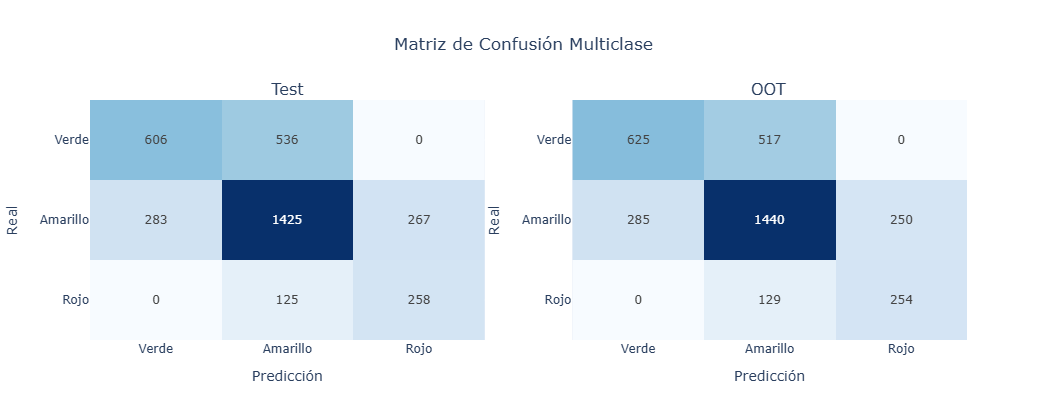

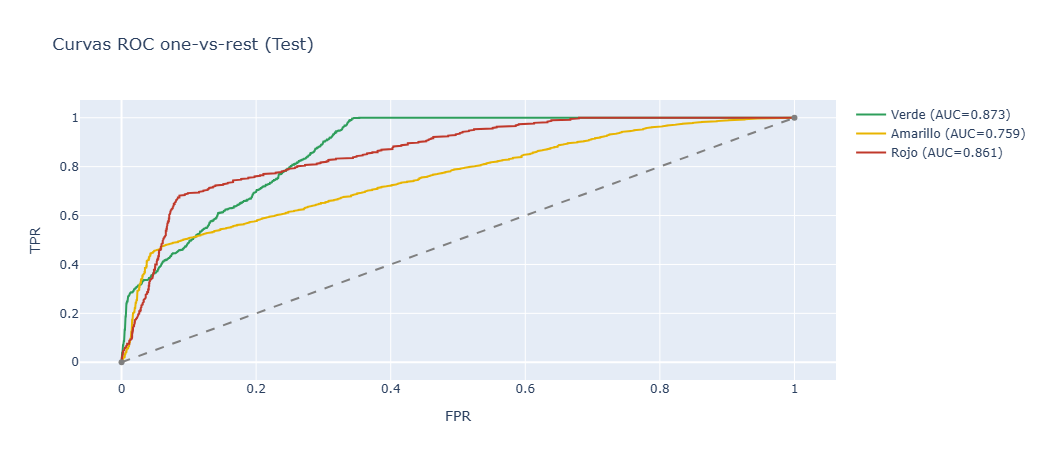

,Test,OOT
accuracy,0.6540,0.6626
balanced_accuracy,0.6419,0.6465
auc_macro,0.8309,0.8329
auc_weighted,0.8074,0.8097
mae,0.3460,0.3374
mse,0.3460,0.3374
qwk,0.5646,0.5726


In [28]:
ETIQ, COL_SEM = ['Verde', 'Amarillo', 'Rojo'], [verde, amarillo, rojo]

# Función de evaluación con predicción ordinal suavizada
def evaluar_multiclase(nombre, y_real, proba):
    yhat = np.clip(np.rint(np.sum(proba * np.arange(proba.shape[1]), axis=1)), 0, 2).astype(int)
    
    met = {
        'accuracy': accuracy_score(y_real, yhat),
        'balanced_accuracy': balanced_accuracy_score(y_real, yhat),
        'auc_macro': roc_auc_score(y_real, proba, multi_class='ovr', average='macro'),
        'auc_weighted': roc_auc_score(y_real, proba, multi_class='ovr', average='weighted'),
        'mae': mean_absolute_error(y_real, yhat),
        'mse': mean_squared_error(y_real, yhat),
        'qwk': cohen_kappa_score(y_real, yhat, weights='quadratic')
    }
    
    print(f'\n========== {nombre} ==========')
    print(f"Acc: {met['accuracy']:.4f} | BalAcc: {met['balanced_accuracy']:.4f} | QWK: {met['qwk']:.4f}")
    print(f"MAE: {met['mae']:.4f} | MSE: {met['mse']:.4f}")
    print('\nReporte:\n', classification_report(y_real, yhat, target_names=ETIQ, digits=3))
    return yhat, met

yhat_te, met_te = evaluar_multiclase('TEST', yc_te.values, rf.predict_proba(Xc_te))
yhat_oo, met_oo = evaluar_multiclase('OUT-OF-TIME', yc_oo.values, rf.predict_proba(Xc_oo))

# Matrices de Confusión
figc = make_subplots(rows=1, cols=2, subplot_titles=('Test', 'OOT'))
for k, (yr, yh) in enumerate([(yc_te.values, yhat_te), (yc_oo.values, yhat_oo)]):
    cm = confusion_matrix(yr, yh, labels=[0, 1, 2])
    figc.add_trace(go.Heatmap(z=cm, x=ETIQ, y=ETIQ, colorscale='Blues', showscale=False, text=cm, texttemplate='%{text}'), row=1, col=k+1)
    figc.update_xaxes(title_text='Predicción', row=1, col=k+1)
    figc.update_yaxes(title_text='Real', autorange='reversed', row=1, col=k+1)
figc.update_layout(height=420, width=900, title_text='Matriz de Confusión Multiclase', title_x=0.5).show()

# Curvas ROC One-vs-Rest
figr = go.Figure()
y_bin = label_binarize(yc_te.values, classes=[0, 1, 2])
for i, (nom, col) in enumerate(zip(ETIQ, COL_SEM)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], rf.predict_proba(Xc_te)[:, i])
    figr.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{nom} (AUC={auc(fpr, tpr):.3f})', line=dict(color=col)))
figr.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='grey'), showlegend=False))
figr.update_layout(title='Curvas ROC one-vs-rest (Test)', xaxis_title='FPR', yaxis_title='TPR', height=460, width=660).show()

pd.DataFrame({'Test': met_te, 'OOT': met_oo}).round(4)

### 4.3 Importancia de variables

Importancia por impureza (Gini) del Random Forest y por permutación sobre el conjunto *out-of-time* (medida como caída de *accuracy*).


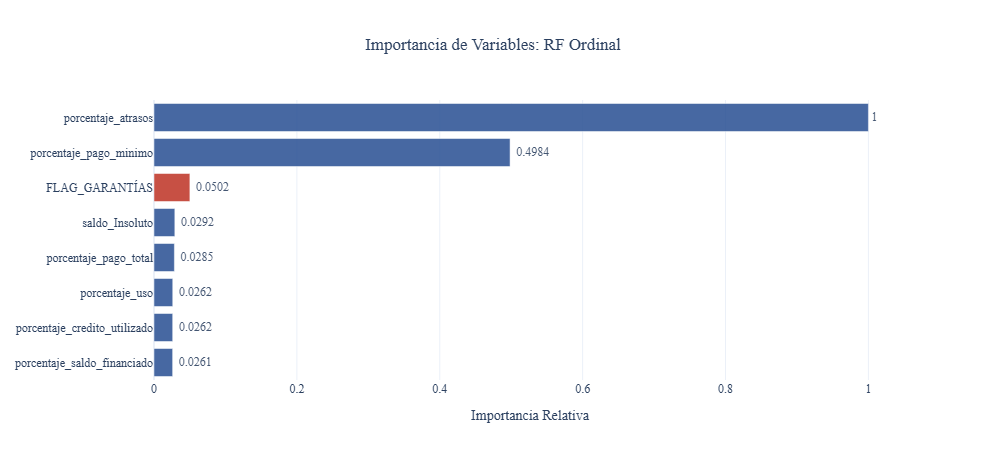

,Variable,Impureza (Gini),Permutación (-MAE),Score_Combinado
2,porcentaje_atrasos,0.5821,0.2985,1.0000
0,porcentaje_pago_minimo,0.2641,0.1688,0.4984
7,FLAG_GARANTÍAS,0.0285,0.0156,0.0502
6,saldo_Insoluto,0.0266,0.0013,0.0292
1,porcentaje_pago_total,0.0266,0.0009,0.0285
5,porcentaje_uso,0.0246,0.0006,0.0262
4,porcentaje_credito_utilizado,0.0237,0.0013,0.0262
3,porcentaje_saldo_financiado,0.0239,0.0011,0.0261


In [29]:
# Cálculo de importancia: Gini y Permutación basada en MAE
imp_perm = permutation_importance(rf, Xc_oo, yc_oo, n_repeats=15, random_state=semilla, scoring='neg_mean_absolute_error', n_jobs=-1)

imp = pd.DataFrame({
    'Variable': vars_cob,
    'Impureza (Gini)': rf.feature_importances_,
    'Permutación (-MAE)': np.abs(imp_perm.importances_mean)
})

# Cálculo del score combinado normalizado
imp['Score_Combinado'] = 0.6 * (imp['Impureza (Gini)'] / imp['Impureza (Gini)'].max()) + \
                         0.4 * (imp['Permutación (-MAE)'] / imp['Permutación (-MAE)'].max())
imp = imp.sort_values('Score_Combinado')

# Visualización de importancia relativa
colores = [rojo if v == 'FLAG_GARANTÍAS' else '#2E5496' for v in imp['Variable']]
fig = go.Figure(go.Bar(x=imp['Score_Combinado'], y=imp['Variable'], orientation='h', marker_color=colores, 
                       text=imp['Score_Combinado'].round(4), textposition='outside', opacity=.88))

fig.update_layout(template='plotly_white', height=460, width=860, title='Importancia de Variables: RF Ordinal', 
                  title_x=0.5, xaxis_title='Importancia Relativa', font=dict(family='serif', size=12)).show()

imp.sort_values('Score_Combinado', ascending=False).round(4)

### 4.4 Semáforo de riesgo — salida del modelo sobre la cartera

La segmentación se obtiene directamente del clasificador, para cada cliente se calculan las probabilidades de pertenecer a cada nivel y se asigna el semáforo correspondiente a la clase con probabilidad máxima (`argmax`).

| Semáforo | Nivel de riesgo | Tratamiento de cobranza |
|---|---|---|
| **Verde** | Bajo | Monitoreo estándar |
| **Amarillo** | Medio | Gestión preventiva: contacto temprano, plan de pagos |
| **Rojo** | Alto | Recuperación: reestructura, gestión intensiva |


In [34]:
# Definición de tratamientos y preparación de la cartera
TRATO = {'Verde': 'Monitoreo estándar', 'Amarillo': 'Gestión preventiva (contacto temprano, plan de pagos)', 'Rojo': 'Recuperación (reestructura, gestión intensiva)'}
cartera = df.copy()
proba_cart = rf.predict_proba(cartera[vars_cob])

# Cálculo de probabilidades y score continuo 
for j, c in enumerate(rf.classes_): cartera[f'prob_{NOM_RIESGO[c]}'] = proba_cart[:, j]
cartera['score_modelo'] = np.clip(np.sum(proba_cart * np.arange(proba_cart.shape[1]), axis=1), 0, 2)
cartera['clase_pred'] = np.rint(cartera['score_modelo']).astype(int)

# Asignación de semáforo, riesgo y tratamiento
cartera['Semáforo'] = cartera['clase_pred'].map(NOM_RIESGO)
cartera['Nivel_riesgo'] = cartera['Semáforo'].map({'Verde': 'Bajo', 'Amarillo': 'Medio', 'Rojo': 'Alto'})
cartera['Tratamiento'] = cartera['Semáforo'].map(TRATO)
cartera['prob_max'] = np.max(proba_cart, axis=1)
cartera['Score_riesgo_100'] = (cartera['score_modelo'] / 2) * 100

# Distribución final y resumen 
dist = cartera['Semáforo'].value_counts().reindex(['Verde', 'Amarillo', 'Rojo']).fillna(0).astype(int)
print('Distribución de la cartera por semáforo (salida del modelo):\n', dist)
print(f"\nScore promedio de riesgo: {cartera['Score_riesgo_100'].mean():.2f}")
print(f"Probabilidad promedio máxima: {cartera['prob_max'].mean():.4f}")

# Visualización de las variables de salida
cols_salida = ['Semáforo', 'Nivel_riesgo', 'Score_riesgo_100', 'prob_Verde', 'prob_Amarillo', 'prob_Rojo', 'prob_max', 'Tratamiento']
cartera[cols_salida].head()

Distribución de la cartera por semáforo (salida del modelo):
 Semáforo
Verde        4392
Amarillo    10471
Rojo         2637
Name: count, dtype: int32

Score promedio de riesgo: 45.08
Probabilidad promedio máxima: 0.5970


,Semáforo,Nivel_riesgo,Score_riesgo_100,prob_Verde,prob_Amarillo,prob_Rojo,prob_max,Tratamiento
0,Amarillo,Medio,58.075438,0.118699,0.601094,0.280207,0.601094,"Gestión preventiva (contacto temprano, plan de..."
1,Verde,Bajo,16.922452,0.717839,0.225872,0.056288,0.717839,Monitoreo estándar
2,Verde,Bajo,21.455769,0.644054,0.282776,0.073169,0.644054,Monitoreo estándar
3,Amarillo,Medio,55.788395,0.174862,0.534509,0.290630,0.534509,"Gestión preventiva (contacto temprano, plan de..."
4,Amarillo,Medio,34.650222,0.515247,0.276501,0.208252,0.515247,"Gestión preventiva (contacto temprano, plan de..."


In [31]:
# Preparación y exportación a Excel
ruta = os.path.join(os.path.dirname(r"C:\Users\rolg0\Downloads\8vo semestre"), 'cartera_semaforo_cobranza.xlsx')
cols_salida = [c for c in ['id_cliente', 'dias_atraso', 'porcentaje_atrasos', 'porcentaje_pago_minimo', 'FLAG_GARANTÍAS', 'score_cobranza', 'Score_riesgo_100', 'prob_Verde', 'prob_Amarillo', 'prob_Rojo', 'prob_max', 'Semáforo', 'Nivel_riesgo', 'Tratamiento'] if c in cartera.columns]
salida = cartera[cols_salida].copy()

cols_red = ['score_cobranza', 'Score_riesgo_100', 'prob_Verde', 'prob_Amarillo', 'prob_Rojo', 'prob_max']
for c in cols_red: 
    if c in salida.columns: salida[c] = salida[c].round(4)

salida.to_excel(ruta, sheet_name='Semaforo_Cartera', index=False)

wb = load_workbook(ruta)
ws = wb['Semaforo_Cartera']
fills = {'Verde': PatternFill('solid', fgColor='92D050'), 'Amarillo': PatternFill('solid', fgColor='FFFF00'), 'Rojo': PatternFill('solid', fgColor='FF0000')}
center = Alignment(horizontal='center', vertical='center')

for cell in ws[1]:
    cell.fill, cell.font, cell.alignment = PatternFill('solid', fgColor='1F497D'), Font(color='FFFFFF', bold=True), center

col_sem = next(c for c in range(1, ws.max_column + 1) if ws.cell(1, c).value == 'Semáforo')
for fila in range(2, ws.max_row + 1):
    celda = ws.cell(fila, col_sem)
    if celda.value in fills: celda.fill = fills[celda.value]
    celda.alignment = center

for col in ws.columns:
    max_len = max([len(str(cell.value)) for cell in col])
    ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 40)

ws.freeze_panes = 'A2'
wb.save(ruta)

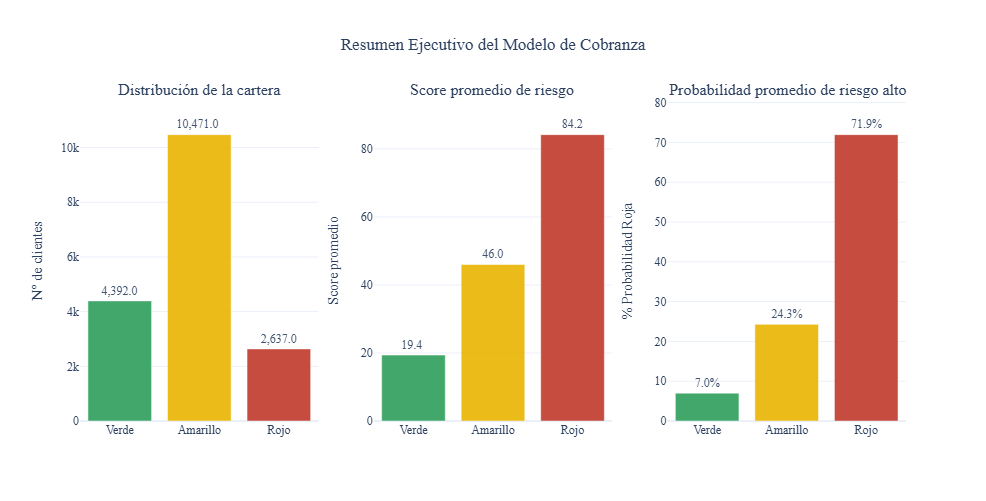

,Semáforo,Nivel_riesgo,Tratamiento,Clientes,Score_promedio,Probabilidad_Roja,Confianza_Modelo
0,Verde,Bajo,Monitoreo estándar,4392,19.3805,0.0700,0.6824
1,Amarillo,Medio,"Gestión preventiva (contacto temprano, plan de...",10471,46.0094,0.2429,0.5303
2,Rojo,Alto,"Recuperación (reestructura, gestión intensiva)",2637,84.1855,0.7195,0.7195


In [32]:
# Preparación de métricas resumidas
resumen_metricas = cartera.groupby('Semáforo').agg({
    'score_cobranza': 'mean', 'Score_riesgo_100': 'mean', 
    'prob_Rojo': 'mean', 'prob_max': 'mean'
}).reindex(['Verde', 'Amarillo', 'Rojo']).fillna(0)

# Creación de la figura principal con subplots
fig = make_subplots(rows=1, cols=3, subplot_titles=('Distribución de la cartera', 'Score promedio de riesgo', 'Probabilidad promedio de riesgo alto'))
bar_data = [dist.values, resumen_metricas['Score_riesgo_100'].values, 100 * resumen_metricas['prob_Rojo'].values]
y_titles = ['N° de clientes', 'Score promedio', '% Probabilidad Roja']

for i, (y_vals, title) in enumerate(zip(bar_data, y_titles)):
    fig.add_trace(go.Bar(x=['Verde', 'Amarillo', 'Rojo'], y=y_vals, marker_color=[verde, amarillo, rojo], 
                         opacity=.90, text=[f'{v:,.1f}' if i == 0 else f'{v:.1f}' + ('%' if i == 2 else '') for v in y_vals],
                         textposition='outside', showlegend=False), row=1, col=i+1)
    fig.update_yaxes(title_text=title, row=1, col=i+1)

fig.update_layout(template='plotly_white', height=440, width=1250, title_text='Resumen Ejecutivo del Modelo de Cobranza', 
                  title_x=0.5, font=dict(family='serif', size=12)).show()

# Procesamiento de la tabla resumen final
resumen_sem = cartera.groupby(['Semáforo', 'Nivel_riesgo', 'Tratamiento']).agg({
    'id_cliente': 'count', 'Score_riesgo_100': 'mean', 'prob_Rojo': 'mean', 'prob_max': 'mean'
}).reset_index()

resumen_sem.columns = ['Semáforo', 'Nivel_riesgo', 'Tratamiento', 'Clientes', 'Score_promedio', 'Probabilidad_Roja', 'Confianza_Modelo']
resumen_sem['orden'] = resumen_sem['Semáforo'].map({'Verde': 0, 'Amarillo': 1, 'Rojo': 2})
resumen_sem = resumen_sem.sort_values('orden').drop(columns='orden').reset_index(drop=True)
resumen_sem[['Score_promedio', 'Probabilidad_Roja', 'Confianza_Modelo']] = resumen_sem[['Score_promedio', 'Probabilidad_Roja', 'Confianza_Modelo']].round(4)

resumen_sem